# Social Vulnerability Ireland - Calculate Vulnerability

## Environment

### R Libraries
The relvant R libraries are imported in to the kernal:

In [1]:
# Load R libraries
if(!require("pacman"))
    install.packages("pacman")

p_load("sf", "tidyverse")

print("Loaded Packages:")
p_loaded()

Loading required package: pacman



[1] "Loaded Packages:"


[1] "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"     "readr"    
 [7] "tidyr"     "tibble"    "ggplot2"   "tidyverse" "sf"        "pacman"

### Output directory

In [2]:
# create the output directory if it does not exist
output_dir <- file.path("../..","3_outputs","Ireland","2022")
if(!dir.exists(output_dir)){
    dir.create(output_dir, recursive = TRUE)
    print(paste0(output_dir, " created"))
}

### Set the GUID

In [3]:
GUID <- "SA_GUID__1"

## Load Data

### Import the data

In [4]:
# Load census data
census_indicator_data <- read.csv("../../2_pipeline/Ireland/1a_CensusData/2022/censusDataZ.csv")
colnames(census_indicator_data)[colnames(census_indicator_data) == "GUID"] = "SA_GUID__1"
head(census_indicator_data)

# Load Coperncius data: tree cover density (TCD) and imperviousness density (IMP)
tcd_indicator_data <- st_read("../../2_pipeline/Ireland/1b_Copernicus/2022/census_areas_TCD.geojson")
imd_indicator_data <- st_read("../../2_pipeline/Ireland/1b_Copernicus/2022/census_areas_IMD.geojson")

# Get the geospatial data from the TCS data (the IMD data also has same spatial data)
oa <- subset(tcd_indicator_data, select = c(GUID, 'geometry'))

# Load vulnerability mapping information from the config file
## This mapping information is used to help guide the amalgamation of the data.
## Weighting can be changed in this file, depending on the scenario.
## Scenario 1 (best case scenario): Weighting values 1 or -1:
##  where 1 means no change
##  or -1 means all the indicator values are multiplied by -1, resulting in an inverse indicator.
## Scenario 2: Weighting values 0.5 or -0.5:
##  For domains with just a single indicators or where there is a lack of information related to missing indicators. 
##  For these domains the weights are halved using a weight of 0.5, or -0.5 for an inverse indicator.
##  Therefore the influence of these indicators are reduced in half.
## Other scenarios are supported by using other decimal numbers if decided for a particular dataset.
indicator_mapping <- read.csv("config/vulnerabilityIndicatorMappings.csv", header=TRUE, sep=",", stringsAsFactors = FALSE, fileEncoding="UTF-8-BOM")

# Print up to 100 rows of vulnerabiltiy mapping config file
head(indicator_mapping,100)

,SA_GUID__1,early_childhood,age_middle_to_oldest_old,poor_health,disability,one_parent_households,three_or_more_children_households,low_skilled_employment,farmers,unemployment,⋯,rented,journey_time,not_volunteers,primary_school_age,one_person_households,no_central_heating,private_water_supply,year_built,mobile_home,unoccupied_dwellings
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4c07d11e-11d3-851d-e053-ca3ca8c0ca7f,-0.1079508,-0.4448091,-0.0867229,-0.4589362,-0.6992867,0.7971503,0.3821265,1.8818244,-0.83703083,⋯,-0.9475582,0.6458280,0.2721853,0.53543614,-0.7988385,-0.7784105,2.8290832,0.1247138,0.9507964,-0.2685905
2,4c07d11e-123a-851d-e053-ca3ca8c0ca7f,-0.2315741,0.7875206,0.1669895,0.5523710,-0.4125867,0.1677345,-0.3005233,1.0930868,-0.26121797,⋯,-0.9117719,0.3856925,-1.2744132,-0.09998755,-0.8885092,0.3283476,2.3937964,0.1865261,-0.1877926,-0.5759916
3,4c07d11e-14b1-851d-e053-ca3ca8c0ca7f,-0.3928420,-0.6320030,1.2441066,0.2624819,0.4618750,-0.3677598,-0.4182116,-0.4741963,0.06414964,⋯,-0.1088473,0.1347198,-0.4611731,0.29209620,-0.4097515,-0.2296817,-0.4744110,-0.5141473,-0.1877926,-0.5772738
4,bf640964-28f3-4ccf-a610-04685d80ea2e,0.7370521,0.3823155,0.3432288,-0.1651002,-0.5449551,-0.6223328,-0.7312063,0.1385892,-0.18265319,⋯,-0.7531121,-0.5219048,-0.7638791,0.28438525,-0.1349893,-0.3651274,0.6291462,0.1706238,0.3058362,-0.5006639
5,4c07d11d-f709-851d-e053-ca3ca8c0ca7f,-0.1666197,-0.3376567,0.1187018,-0.8724183,-0.3649398,0.2410678,-0.3254920,1.6827210,-0.28372469,⋯,-1.0212046,0.3517089,-0.4219533,0.36431183,-0.1519057,0.6567264,2.2075847,0.4902435,0.6692771,-0.3823238
6,4c07d11e-1237-851d-e053-ca3ca8c0ca7f,0.1772575,0.2407678,0.5828047,0.8390637,-0.4233032,0.4107411,0.7385225,1.5548942,0.45793149,⋯,-0.7493154,0.9712513,-0.9921427,0.24013874,-0.6550195,-0.2296817,0.3011058,0.7315812,0.4676137,-0.3881432


Reading layer `census_areas_TCD' from data source 
  `/Cities/2_pipeline/Ireland/1b_Copernicus/2022/census_areas_TCD.geojson' 
  using driver `GeoJSON'
Simple feature collection with 18919 features and 32 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 417471.5 ymin: 519663.7 xmax: 734481.1 ymax: 966896.3
Projected CRS: IRENET95 / Irish Transverse Mercator
Reading layer `census_areas_IMD' from data source 
  `/Cities/2_pipeline/Ireland/1b_Copernicus/2022/census_areas_IMD.geojson' 
  using driver `GeoJSON'
Simple feature collection with 18919 features and 32 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 417471.5 ymin: 519663.7 xmax: 734481.1 ymax: 966896.3
Projected CRS: IRENET95 / Irish Transverse Mercator


,domain,indicator,sensitivity,prepare,respond,recover,adaptive_capacity,enhanced_exposure,weight
,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,age,early_childhood,1,0,0,0,0,0,1
2,age,age_middle_to_oldest_old,1,0,0,0,0,0,1
3,health,poor_health,1,0,0,0,0,0,1
4,health,disability,1,0,0,0,0,0,1
5,income,one_parent_households,0,1,1,1,1,0,1
6,income,three_or_more_children_households,0,1,1,1,1,0,1
7,income,low_skilled_employment,0,1,1,1,1,0,1
8,income,farmers,0,1,1,1,1,0,1
9,income,unemployment,0,1,1,1,1,0,1


## Prepare Data

### Combine data into a single indicator dataset

In [5]:
# combine census data with copernicus TCD and IMD data (without geospatial data to advoid duplication)
indicator_data <- merge(tcd_indicator_data, st_drop_geometry(census_indicator_data), by.x = GUID, by.y = GUID, all.x = TRUE)
indicator_data <- merge(imd_indicator_data, st_drop_geometry(indicator_data), by=GUID)

# drop the geometry
indicator_data <- st_drop_geometry(indicator_data)

# change the small area id column data type (GUID) to character string
indicator_data[GUID] <- lapply(indicator_data[GUID], as.character)

# trim the columns
indicator_data <- subset(indicator_data, select=c(names(census_indicator_data), 'tree_cover_density', 'impervious'))

# Set missing data fields to zero (0)
# Note: In Italian census the NA or empty data fields are areas with no population (e.g. parks, schools, etc.)
indicator_data[is.na(indicator_data)] <- 0

# Print the first part of the indicators, which are now collated into one table
head(indicator_data)

,SA_GUID__1,early_childhood,age_middle_to_oldest_old,poor_health,disability,one_parent_households,three_or_more_children_households,low_skilled_employment,farmers,unemployment,⋯,not_volunteers,primary_school_age,one_person_households,no_central_heating,private_water_supply,year_built,mobile_home,unoccupied_dwellings,tree_cover_density,impervious
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,000581a3-4ebd-4a74-b5f8-0bd78cd7ede5,3.3880435,-0.8683184,-0.72494112,-0.92235833,-0.9537932,-0.28864382,-0.3191812,-0.5775435,-0.61650259,⋯,0.88627118,1.7138413,-1.4596182731,-0.7784105,-0.5390374,-0.8371139,-0.1877926,-0.2345322,0.7388976,-0.3062498
2,00275248-3d78-4fdb-8e5c-8ff1f76aebea,-1.2041476,1.0830212,0.27801178,-0.62611003,-0.5813707,0.24855343,-0.7175350,0.2814244,-0.23523246,⋯,-0.81754631,-0.5610249,-0.0009715101,-0.7784105,1.3835981,-0.4334056,-0.1877926,-0.3975997,0.1744364,-0.4046076
3,002b83e4-5cce-414a-8570-871a50ae0964,0.2940109,-0.6563918,0.07647292,0.06773408,0.3083236,-0.06192013,-0.7370951,-0.1126775,0.22240140,⋯,0.52365099,0.3585112,-0.2053615213,-0.1120970,-0.5390374,-0.7250643,-0.1877926,-0.5907831,0.3864675,0.2528562
4,005eec3f-d746-480f-ae2c-bc6f1151548d,-1.3337162,1.4547264,0.49313225,0.45603900,-1.0918818,-1.18351563,-1.9157382,-0.5775435,-0.07660151,⋯,-0.27505307,-1.3574765,-0.6525911498,-0.1318884,-0.3106055,-0.7827532,-0.1877926,-0.3274716,0.7008530,0.5785962
5,00b00ae4-229d-455d-84f1-d6face4876b1,1.7131001,-1.2060316,-0.32805634,-0.03080027,3.2416831,1.26642096,1.5271694,-0.5775435,0.75768133,⋯,1.59439615,2.9123134,-1.1159542610,-0.7784105,-0.5390374,-0.7424513,-0.1877926,-0.6509695,0.4060470,0.5467661
6,00df2b78-66c8-4009-89e0-0e14e15e4208,1.5084163,-0.8589597,-1.03118100,-1.02730679,-0.4959203,-0.57201990,0.4816479,-0.4599295,-0.97841257,⋯,-0.02986993,0.6262758,-0.9415702944,-0.7784105,-0.5390374,-0.6196710,-0.1877926,-0.4166064,0.7989094,-0.4272128


### Weight the indicator datas 

In [6]:
# Get the indicator weighting, previously loaded from the config file
indicator_weighting <- indicator_mapping %>% select('indicator', 'weight')
indicator_weighting <- indicator_weighting %>% spread(key = 'indicator', value = 'weight')

# Get the column names and weights
names <- names(indicator_weighting)
weights <- indicator_weighting[, names]

# Copy and rename the dataset
indicator_data_weighted <- indicator_data
head(indicator_data_weighted) 

# Multiply the indicators by the config file weighting
indicator_data_weighted[, names] <- sweep(indicator_data_weighted[, names], 2, unlist(weights[, names]), "*")
head(indicator_data_weighted)

,SA_GUID__1,early_childhood,age_middle_to_oldest_old,poor_health,disability,one_parent_households,three_or_more_children_households,low_skilled_employment,farmers,unemployment,⋯,not_volunteers,primary_school_age,one_person_households,no_central_heating,private_water_supply,year_built,mobile_home,unoccupied_dwellings,tree_cover_density,impervious
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,000581a3-4ebd-4a74-b5f8-0bd78cd7ede5,3.3880435,-0.8683184,-0.72494112,-0.92235833,-0.9537932,-0.28864382,-0.3191812,-0.5775435,-0.61650259,⋯,0.88627118,1.7138413,-1.4596182731,-0.7784105,-0.5390374,-0.8371139,-0.1877926,-0.2345322,0.7388976,-0.3062498
2,00275248-3d78-4fdb-8e5c-8ff1f76aebea,-1.2041476,1.0830212,0.27801178,-0.62611003,-0.5813707,0.24855343,-0.7175350,0.2814244,-0.23523246,⋯,-0.81754631,-0.5610249,-0.0009715101,-0.7784105,1.3835981,-0.4334056,-0.1877926,-0.3975997,0.1744364,-0.4046076
3,002b83e4-5cce-414a-8570-871a50ae0964,0.2940109,-0.6563918,0.07647292,0.06773408,0.3083236,-0.06192013,-0.7370951,-0.1126775,0.22240140,⋯,0.52365099,0.3585112,-0.2053615213,-0.1120970,-0.5390374,-0.7250643,-0.1877926,-0.5907831,0.3864675,0.2528562
4,005eec3f-d746-480f-ae2c-bc6f1151548d,-1.3337162,1.4547264,0.49313225,0.45603900,-1.0918818,-1.18351563,-1.9157382,-0.5775435,-0.07660151,⋯,-0.27505307,-1.3574765,-0.6525911498,-0.1318884,-0.3106055,-0.7827532,-0.1877926,-0.3274716,0.7008530,0.5785962
5,00b00ae4-229d-455d-84f1-d6face4876b1,1.7131001,-1.2060316,-0.32805634,-0.03080027,3.2416831,1.26642096,1.5271694,-0.5775435,0.75768133,⋯,1.59439615,2.9123134,-1.1159542610,-0.7784105,-0.5390374,-0.7424513,-0.1877926,-0.6509695,0.4060470,0.5467661
6,00df2b78-66c8-4009-89e0-0e14e15e4208,1.5084163,-0.8589597,-1.03118100,-1.02730679,-0.4959203,-0.57201990,0.4816479,-0.4599295,-0.97841257,⋯,-0.02986993,0.6262758,-0.9415702944,-0.7784105,-0.5390374,-0.6196710,-0.1877926,-0.4166064,0.7989094,-0.4272128


,SA_GUID__1,early_childhood,age_middle_to_oldest_old,poor_health,disability,one_parent_households,three_or_more_children_households,low_skilled_employment,farmers,unemployment,⋯,not_volunteers,primary_school_age,one_person_households,no_central_heating,private_water_supply,year_built,mobile_home,unoccupied_dwellings,tree_cover_density,impervious
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,000581a3-4ebd-4a74-b5f8-0bd78cd7ede5,3.3880435,-0.8683184,-0.72494112,-0.92235833,-0.9537932,-0.28864382,-0.3191812,-0.5775435,-0.61650259,⋯,0.88627118,-1.7138413,-1.4596182731,-0.7784105,-0.5390374,-0.8371139,-0.1877926,-0.2345322,0.7388976,-0.3062498
2,00275248-3d78-4fdb-8e5c-8ff1f76aebea,-1.2041476,1.0830212,0.27801178,-0.62611003,-0.5813707,0.24855343,-0.7175350,0.2814244,-0.23523246,⋯,-0.81754631,0.5610249,-0.0009715101,-0.7784105,1.3835981,-0.4334056,-0.1877926,-0.3975997,0.1744364,-0.4046076
3,002b83e4-5cce-414a-8570-871a50ae0964,0.2940109,-0.6563918,0.07647292,0.06773408,0.3083236,-0.06192013,-0.7370951,-0.1126775,0.22240140,⋯,0.52365099,-0.3585112,-0.2053615213,-0.1120970,-0.5390374,-0.7250643,-0.1877926,-0.5907831,0.3864675,0.2528562
4,005eec3f-d746-480f-ae2c-bc6f1151548d,-1.3337162,1.4547264,0.49313225,0.45603900,-1.0918818,-1.18351563,-1.9157382,-0.5775435,-0.07660151,⋯,-0.27505307,1.3574765,-0.6525911498,-0.1318884,-0.3106055,-0.7827532,-0.1877926,-0.3274716,0.7008530,0.5785962
5,00b00ae4-229d-455d-84f1-d6face4876b1,1.7131001,-1.2060316,-0.32805634,-0.03080027,3.2416831,1.26642096,1.5271694,-0.5775435,0.75768133,⋯,1.59439615,-2.9123134,-1.1159542610,-0.7784105,-0.5390374,-0.7424513,-0.1877926,-0.6509695,0.4060470,0.5467661
6,00df2b78-66c8-4009-89e0-0e14e15e4208,1.5084163,-0.8589597,-1.03118100,-1.02730679,-0.4959203,-0.57201990,0.4816479,-0.4599295,-0.97841257,⋯,-0.02986993,-0.6262758,-0.9415702944,-0.7784105,-0.5390374,-0.6196710,-0.1877926,-0.4166064,0.7989094,-0.4272128


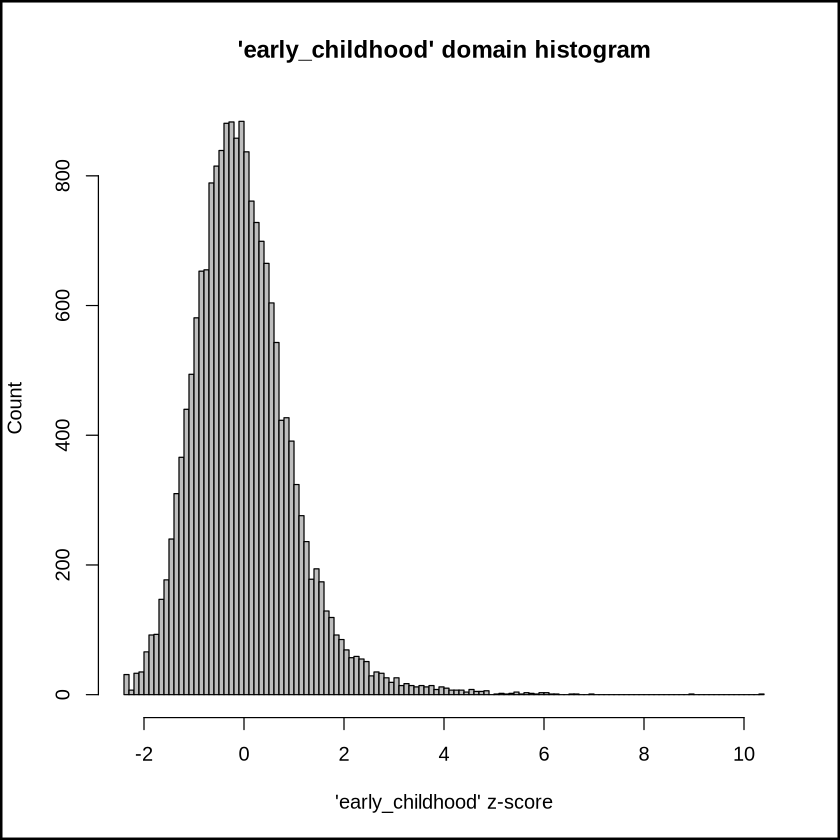

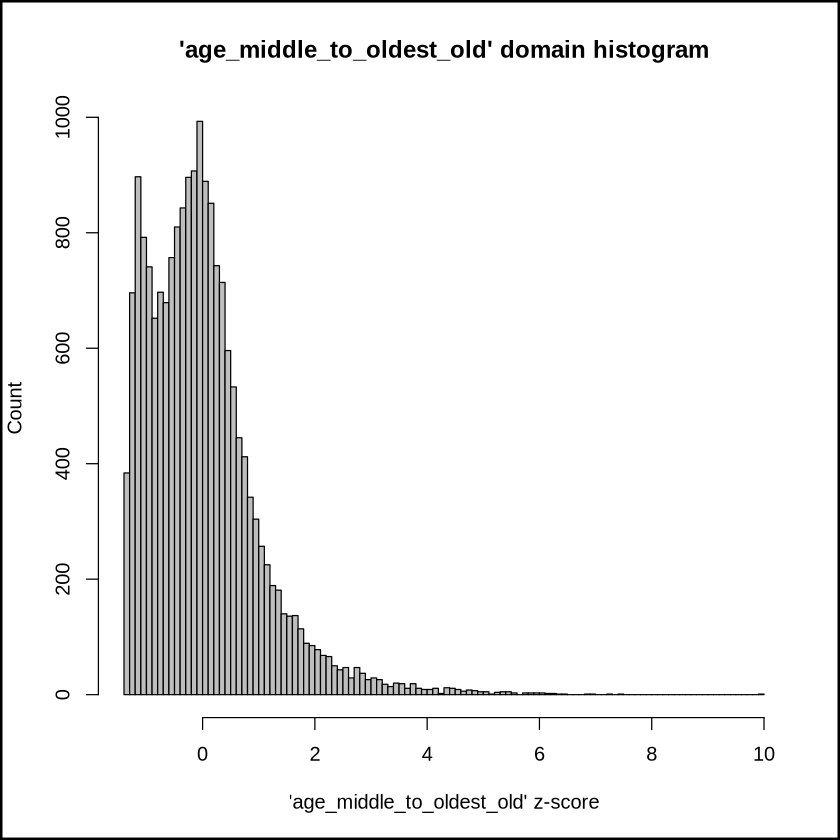

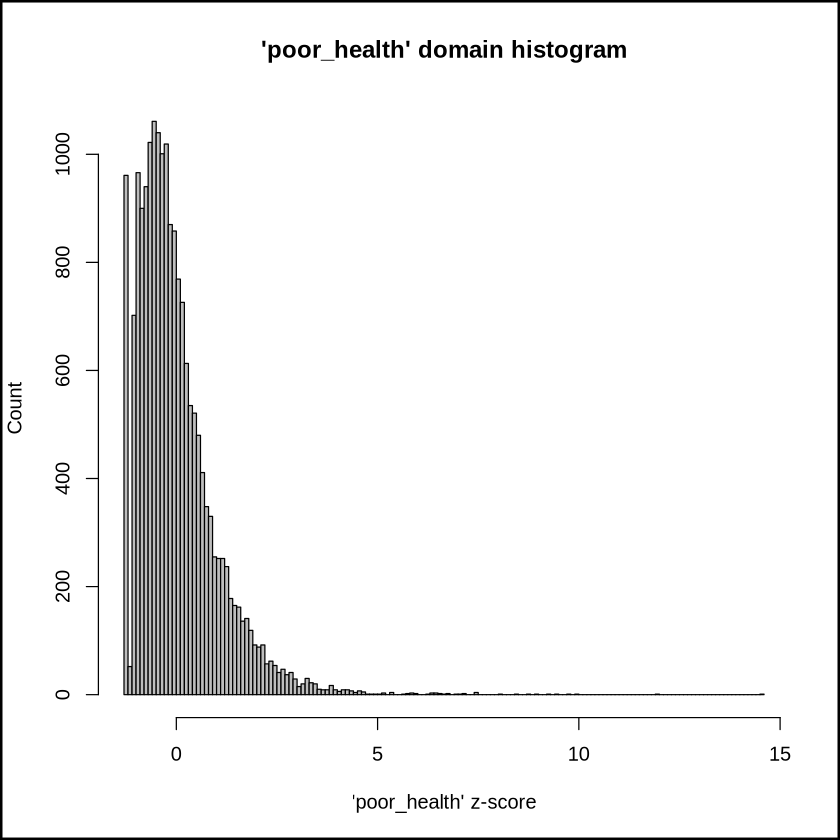

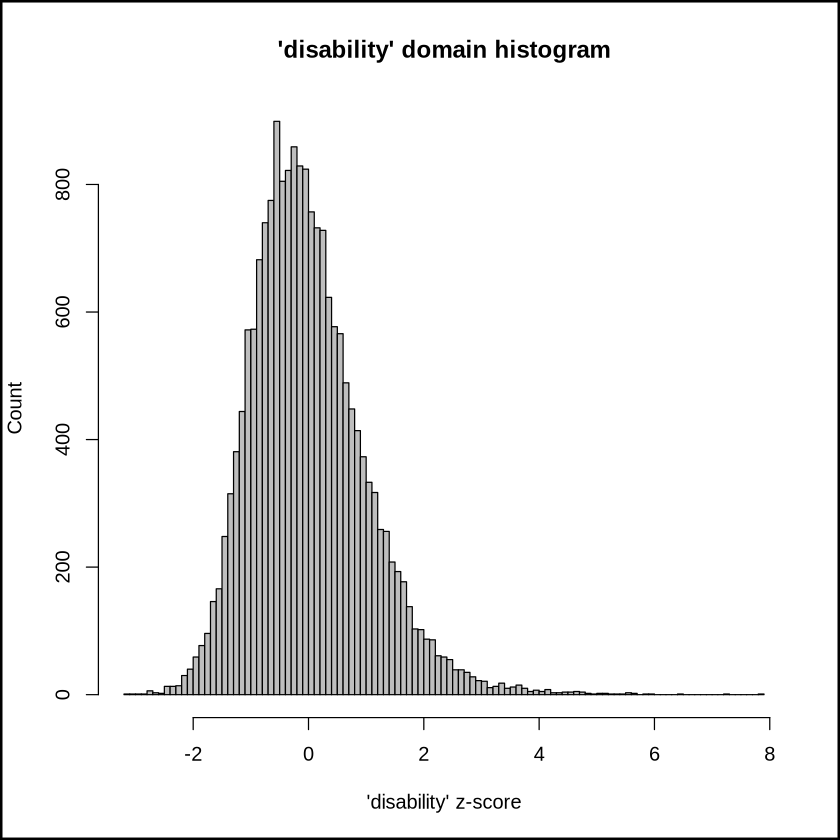

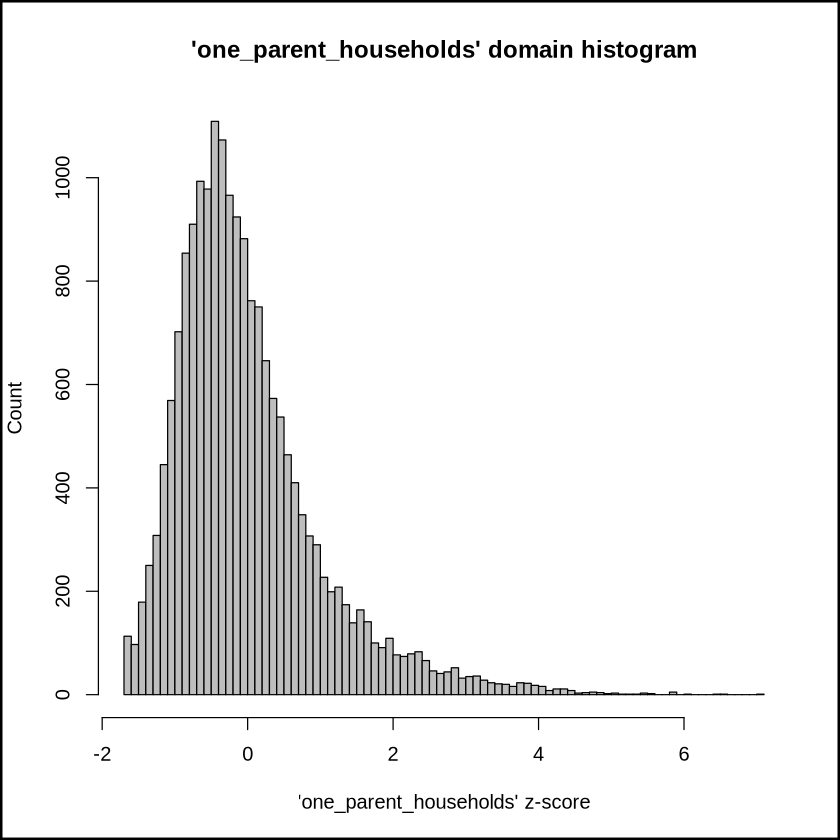

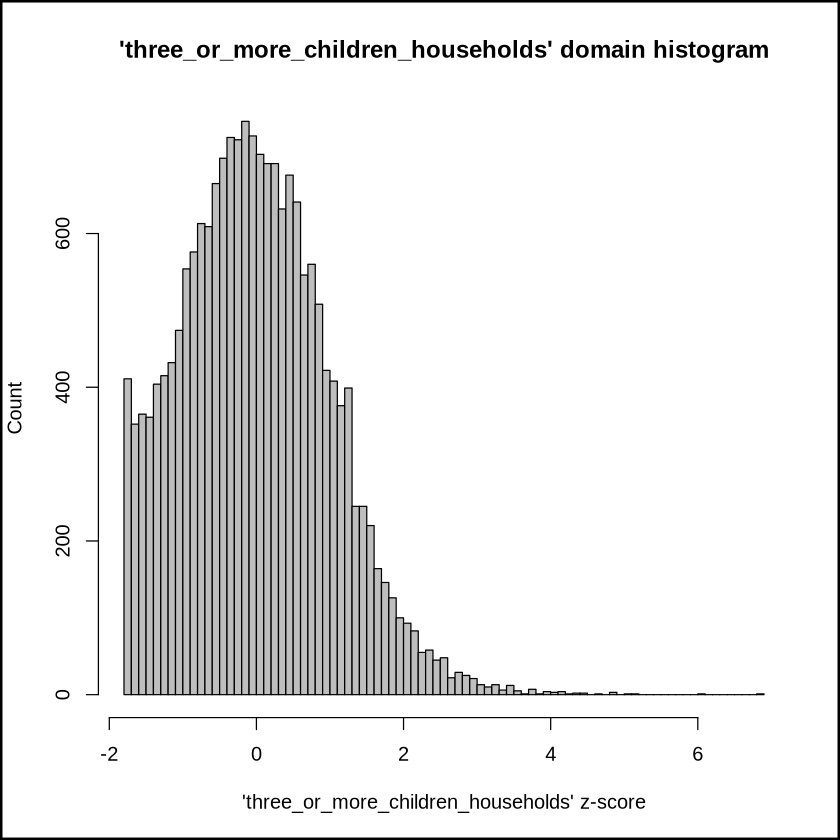

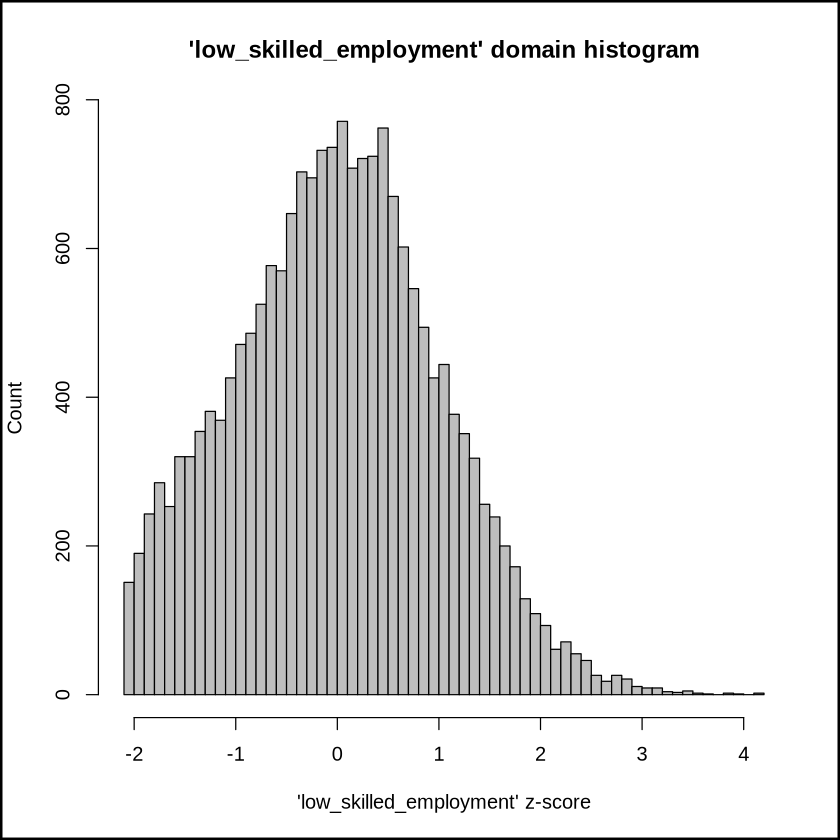

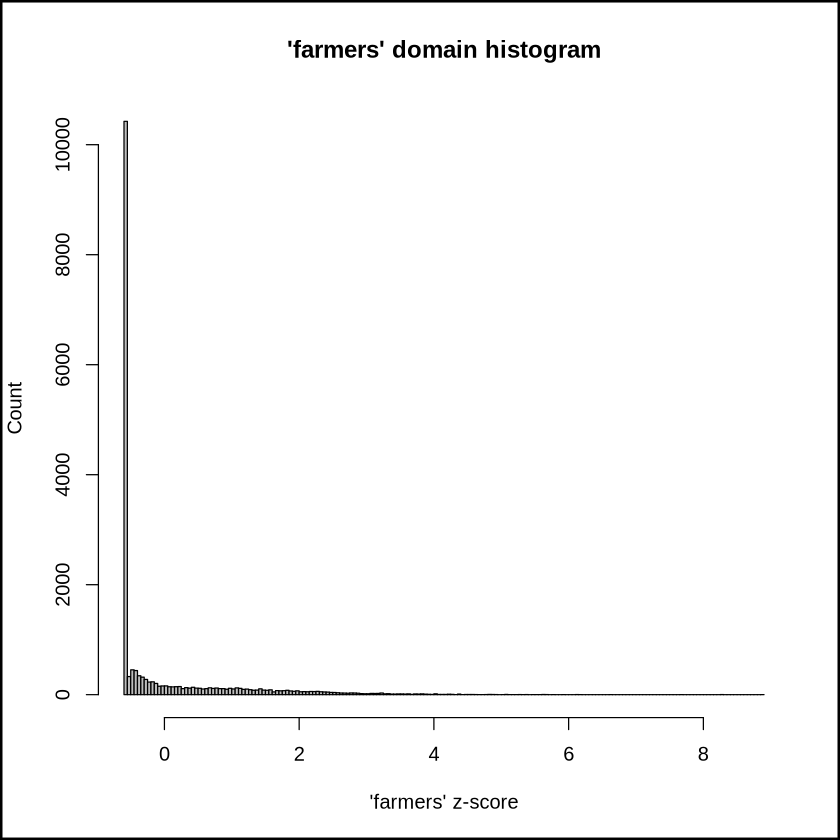

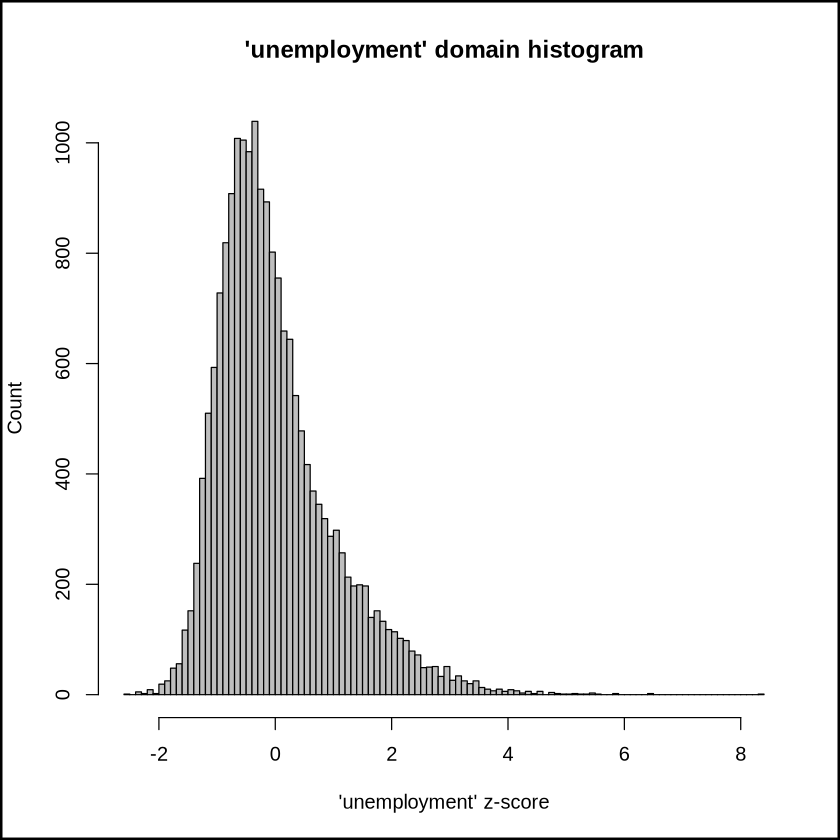

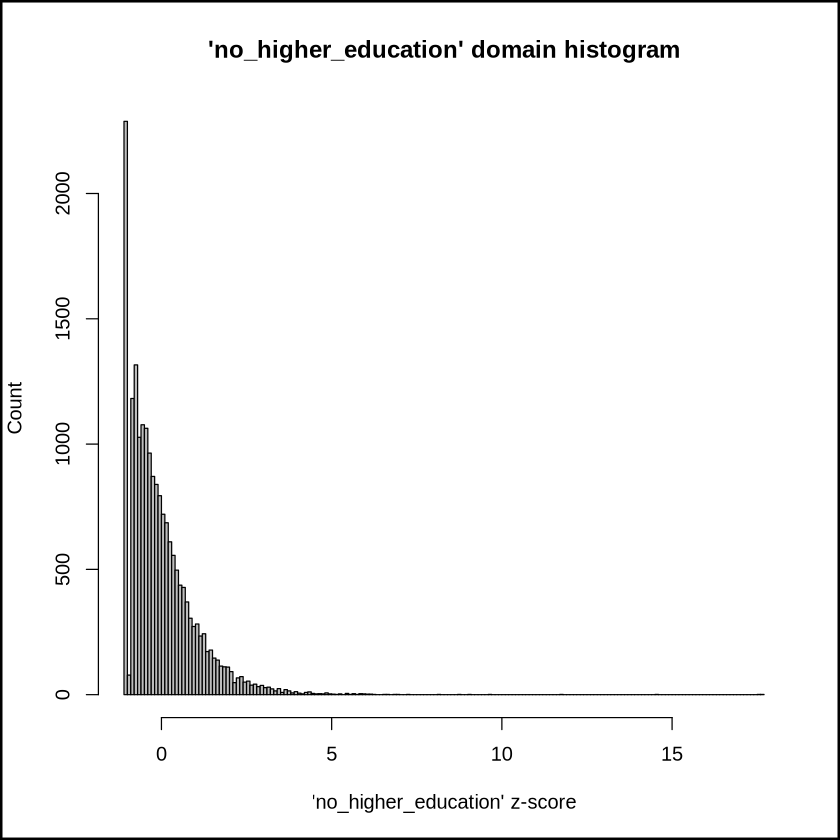

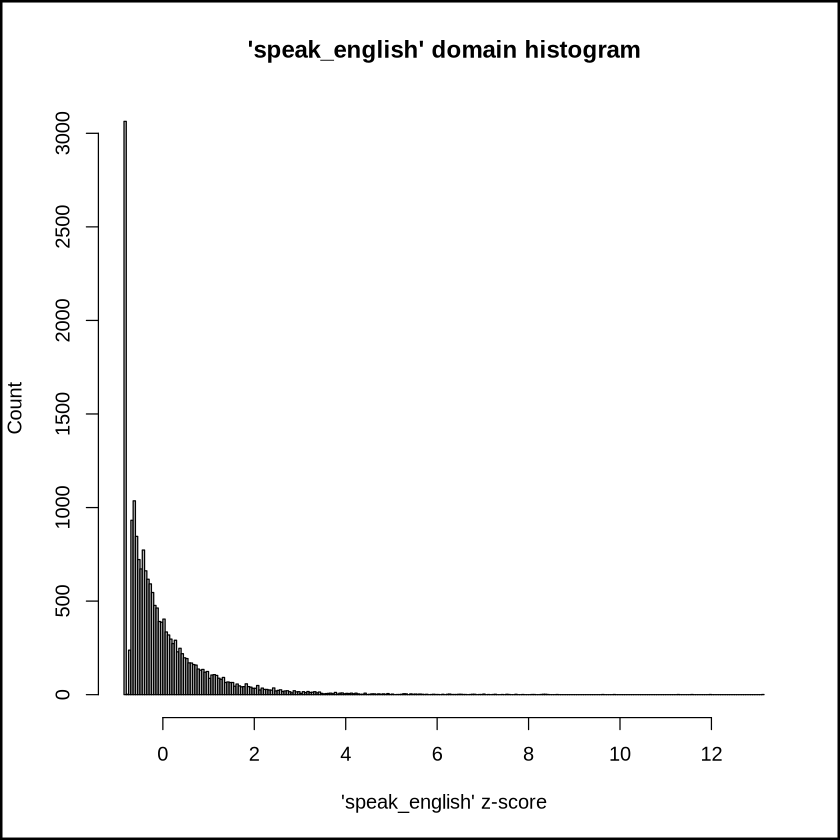

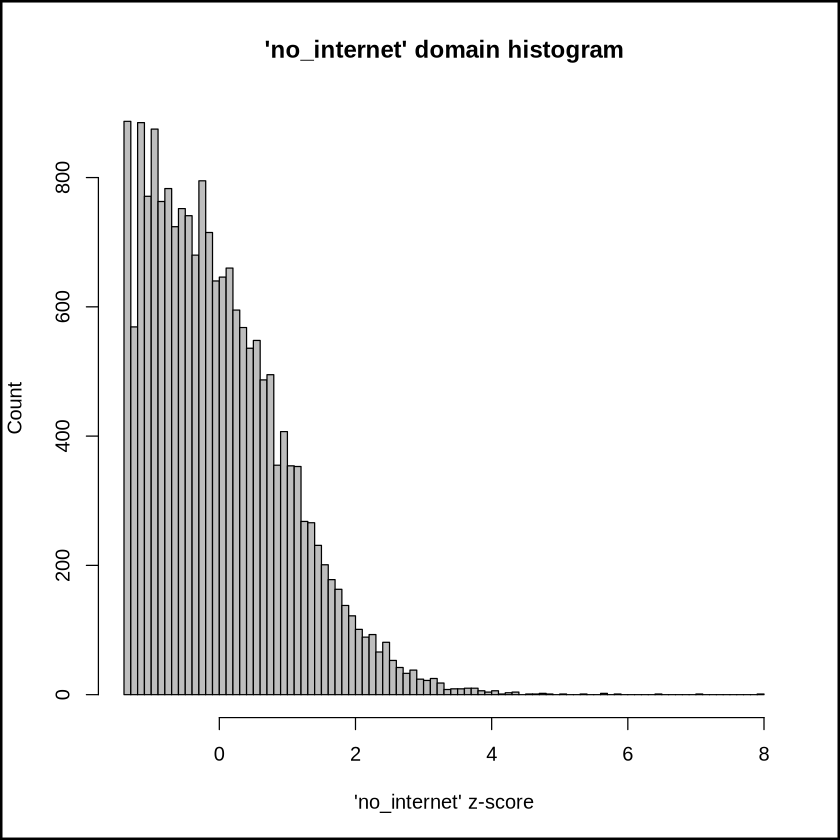

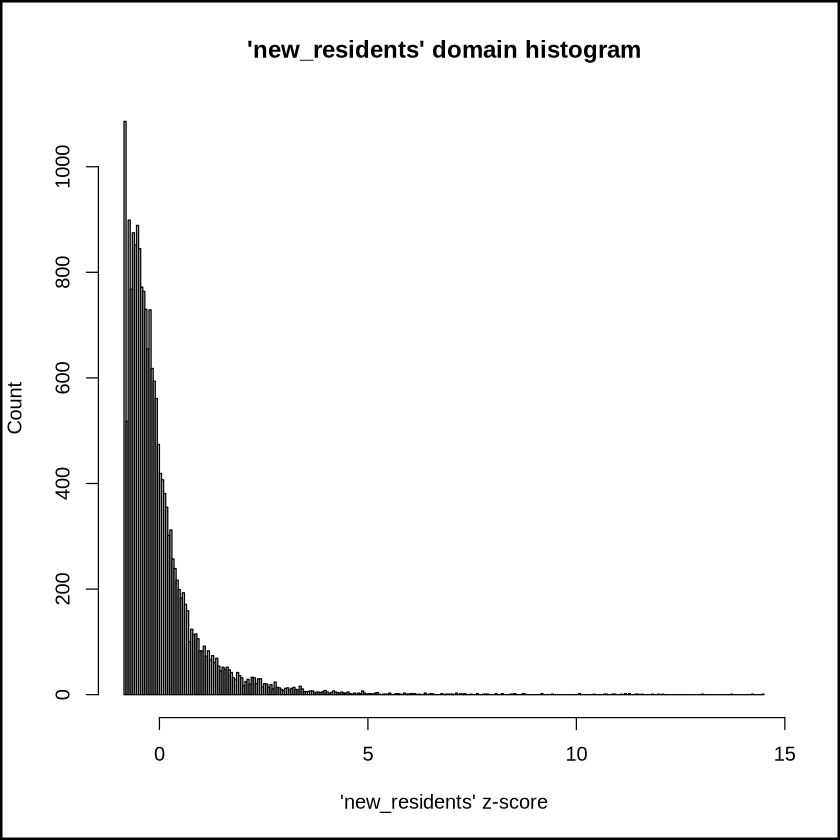

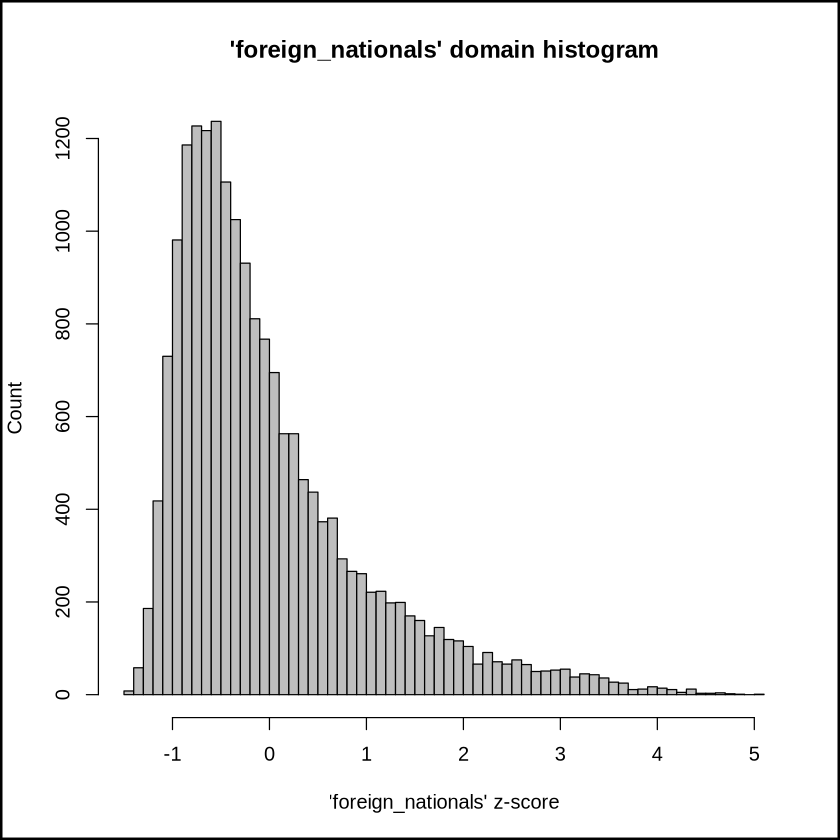

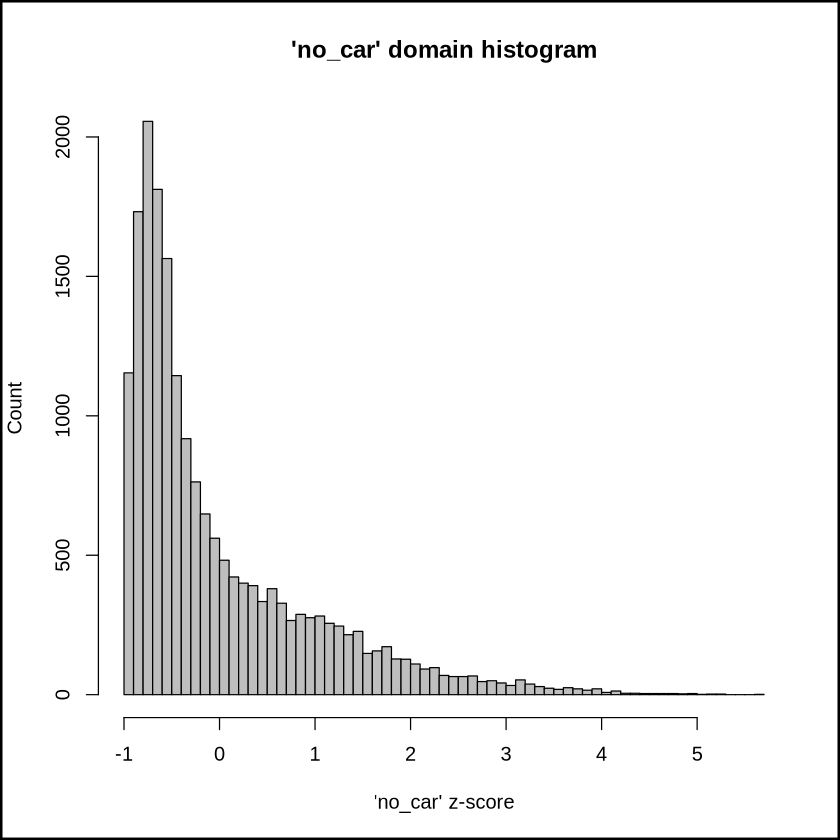

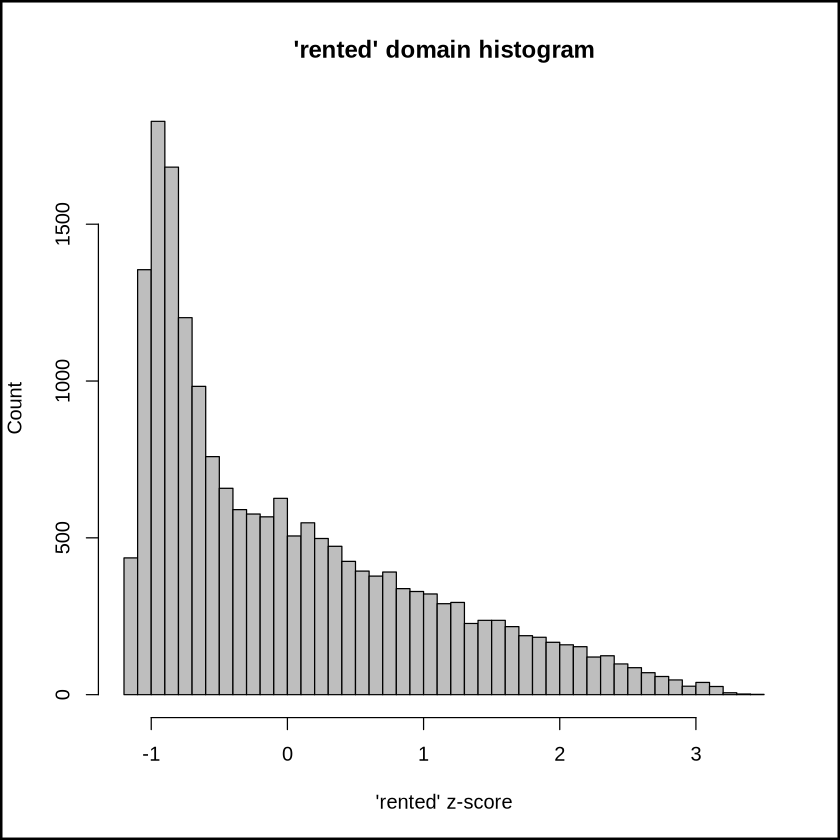

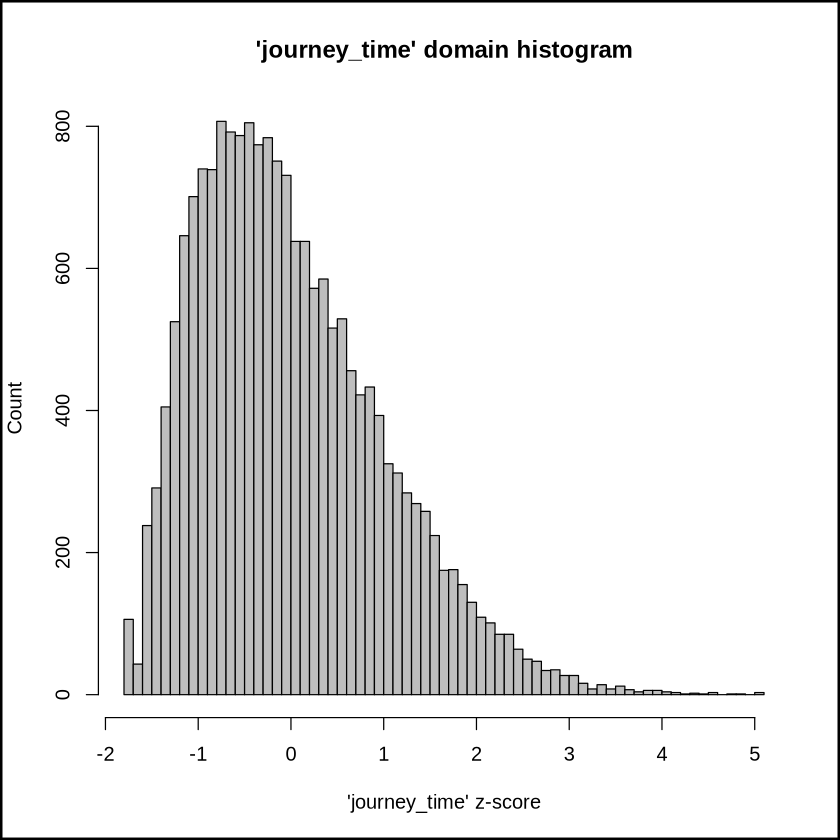

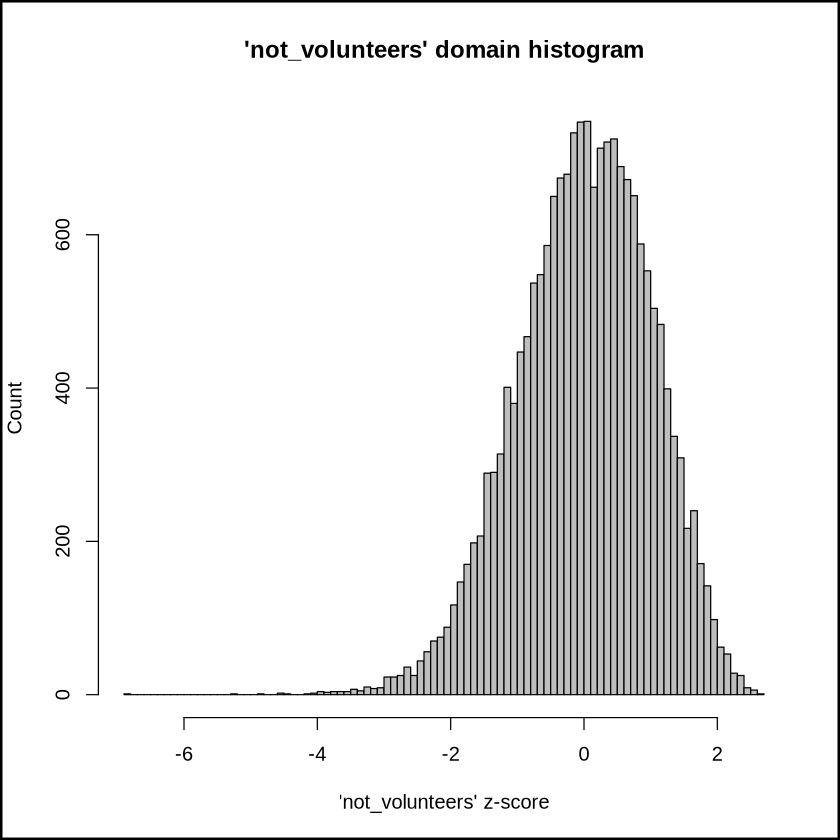

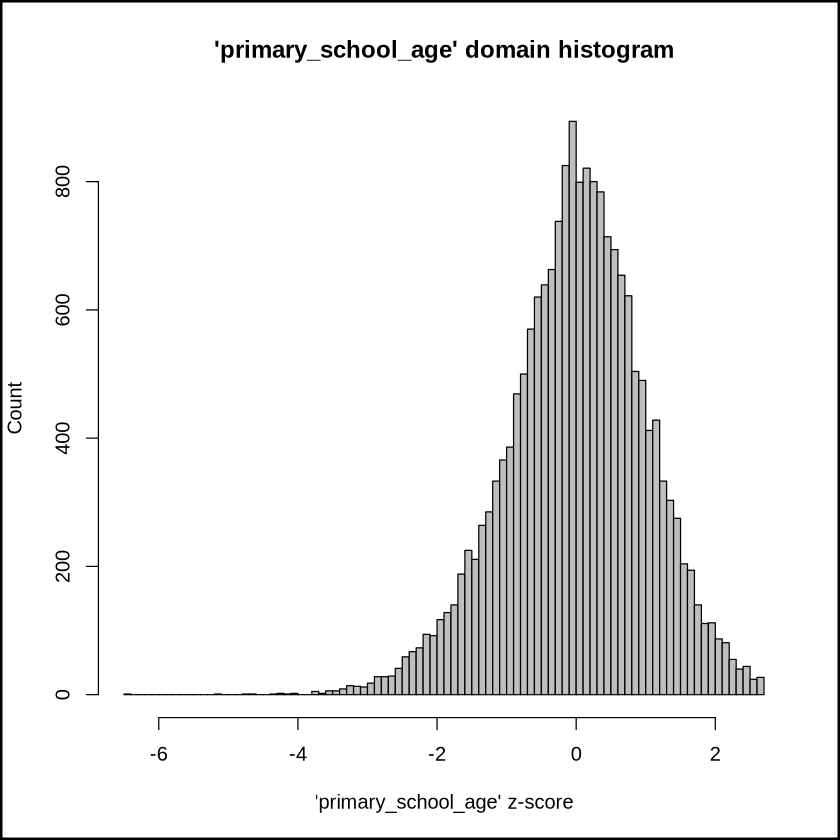

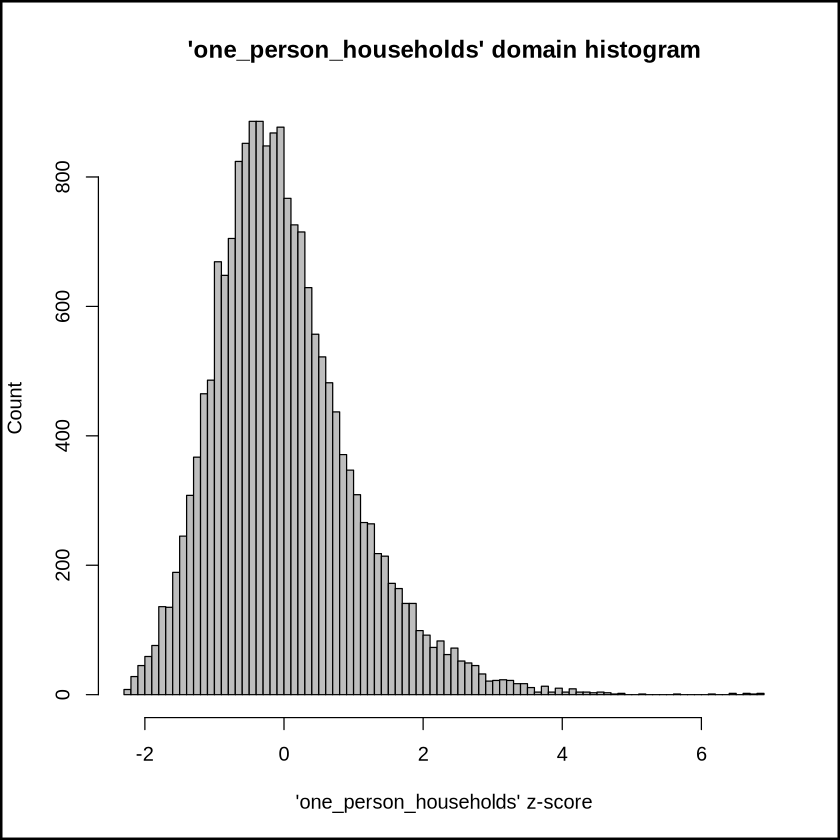

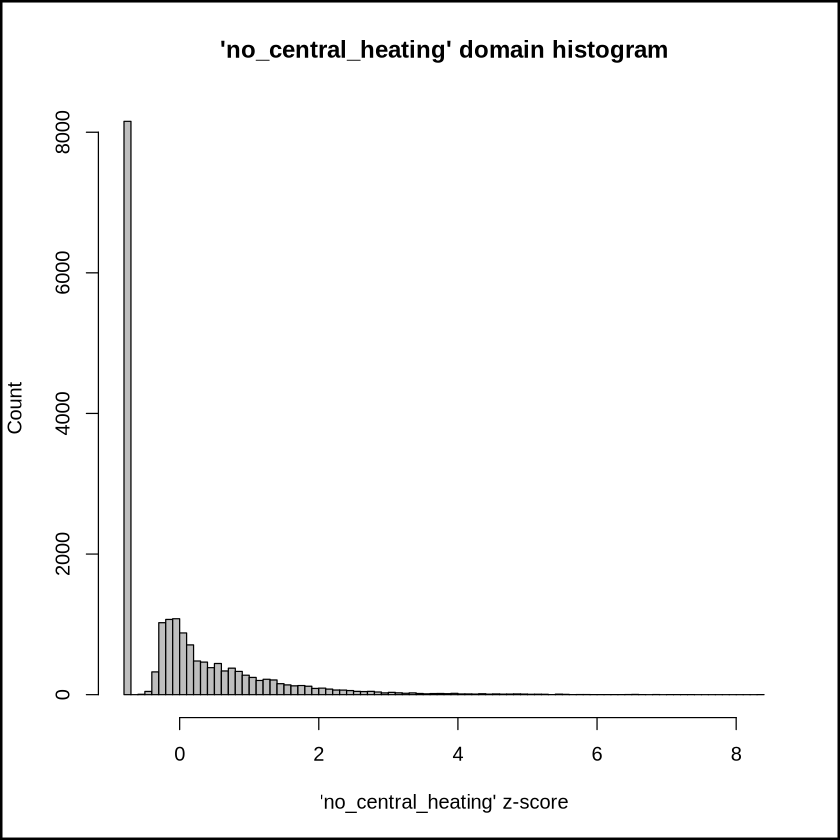

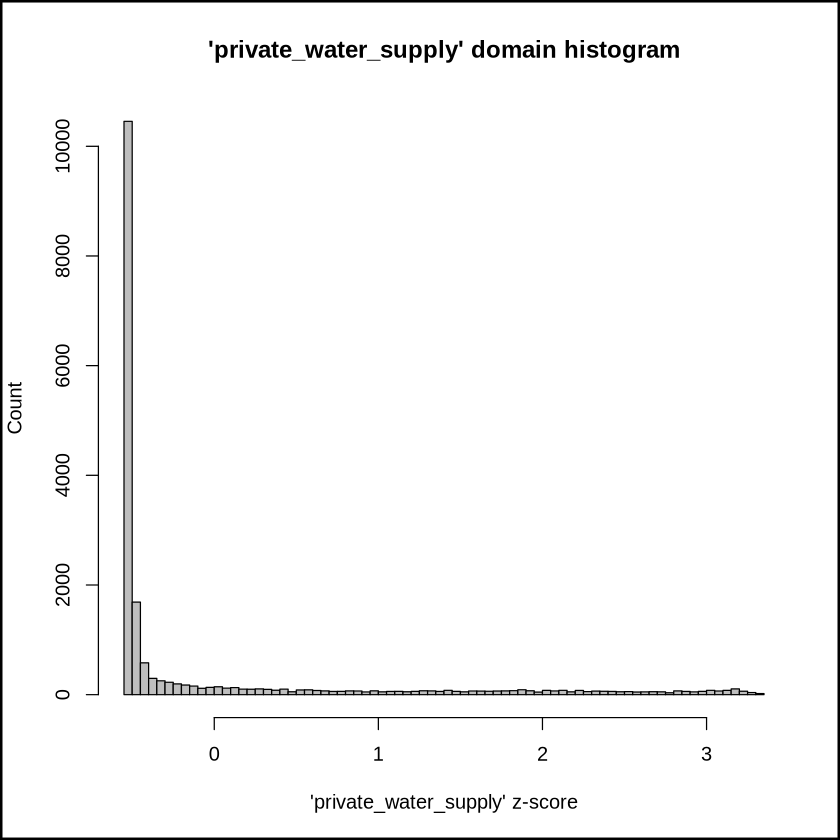

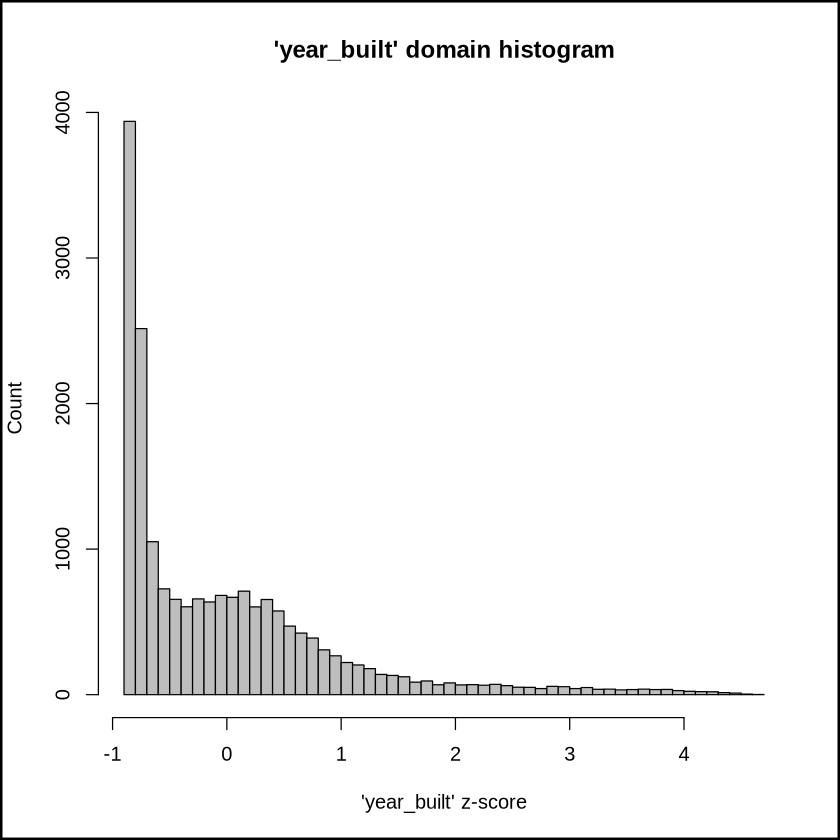

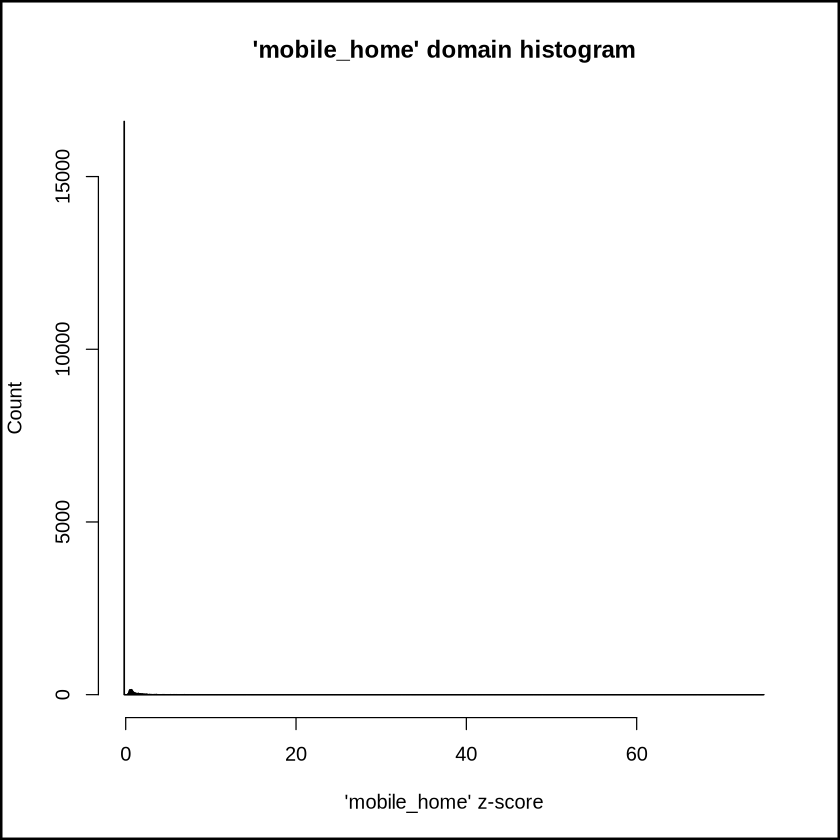

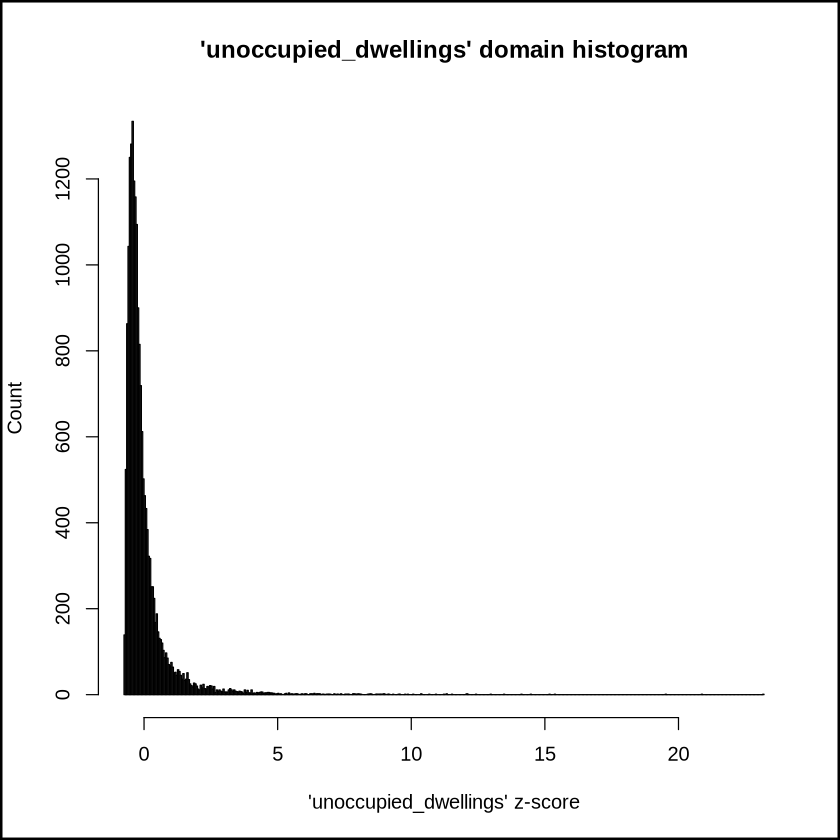

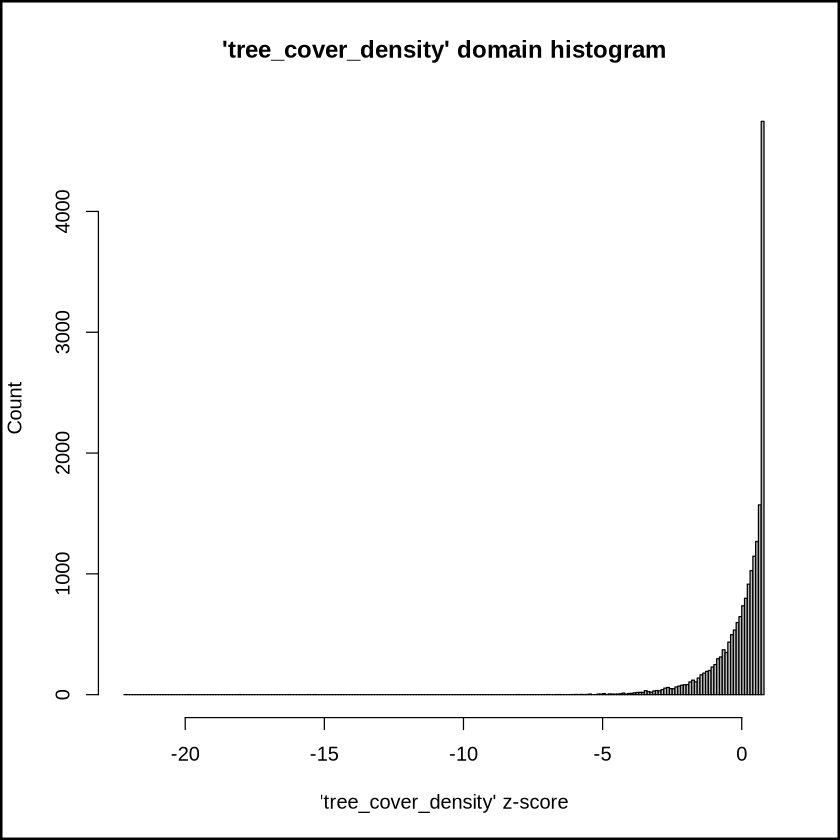

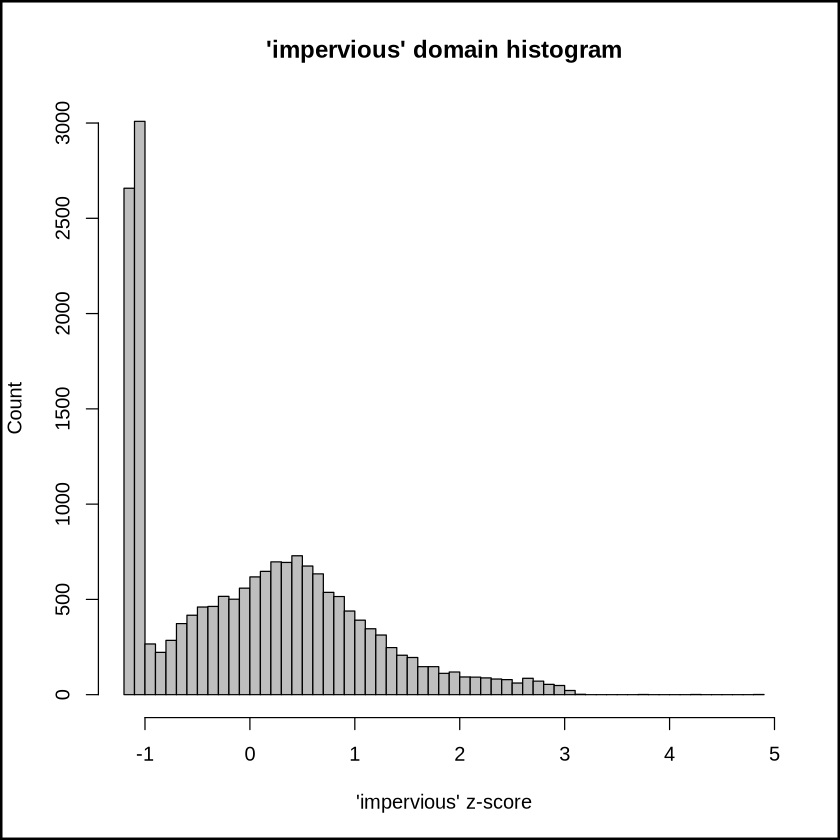

In [7]:
# Histogram visualisation of weighted indicators
indicator_columns <- colnames(indicator_data_weighted)[-1]
for( current_indicator_column in indicator_columns ) {
    indicator_filtered <- indicator_data_weighted[,current_indicator_column] 
    indicator_filtered[indicator_filtered == "NaN"] <- 0

    title <- paste("'", current_indicator_column, "' domain histogram", sep = "")
    x_label <- paste("'", current_indicator_column, "' z-score", sep = "")
    y_label <- paste("Count", sep = "")
    hist(indicator_filtered, breaks="FD", col="grey", labels = FALSE, main=title, xlab=x_label, ylab=y_label)
    box("figure", lwd = 4)
}

## Process social vulnerability scores

### Calculate domain scores

In [8]:
# Get the domains and their associated indicator ID
domain_indicators <- indicator_mapping %>% select('domain', 'indicator')

# Get a vector/array of the unique domain names
unique_domains <- unique(domain_indicators$domain)

# Initialise the domain score dataset with the GUID
domain_scores <- indicator_data_weighted %>% select(all_of(GUID))

# Loop through each domain
for (current_domain in unique_domains) {
    # Identify which indicators are used within this domain (current_domain)
    current_domain_info <- domain_indicators %>% filter(domain == current_domain)

    # Count the number of indicators in this domain
    domain_indicator_count <- length(current_domain_info$indicator)

    # Get a vector/array of the indicators used by this domain, and add the GUID column name
    current_domain_indicators <- current_domain_info$indicator
    current_domain_indicators <- (c(GUID, current_domain_indicators))

    # filter the dataset to only use the indicators in the domain
    current_domain_data <- indicator_data_weighted[current_domain_indicators]

    # Calculate the internal weight distribution for the indicators within this domain,
    # using an equal weight distribution across this domain
    internal_domain_weight <- 1.0 / domain_indicator_count

    # Internally weight the data for this domain
    current_domain_data_weighted <- current_domain_data %>% mutate_if(is.numeric, function(x) {x*internal_domain_weight})

    # Sum each data row to get the total score for the domain
    current_domain_data_weighted[, current_domain] <- rowSums(current_domain_data_weighted[2:(domain_indicator_count+1)], na.rm = TRUE)

    # Add the current domain score to the overall results
    domain_indicator_score <- current_domain_data_weighted %>% select(all_of(GUID), all_of(current_domain))
    domain_scores <- merge(domain_scores, domain_indicator_score, by=GUID)
}

# Print the first part of the domain z-scores, which are now collated into one table
head(domain_scores)

,SA_GUID__1,age,health,income,info_access_use,local_knowledge,mobility,physical_access,tenure,social_network,housing_characteristics,physical_environment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,000581a3-4ebd-4a74-b5f8-0bd78cd7ede5,1.25986257,-0.8236497,-0.55113286,-0.3552132,0.5916092,-0.80430587,1.0782176,-0.6291412,-0.76239614,-0.51537733,0.2163239
2,00275248-3d78-4fdb-8e5c-8ff1f76aebea,-0.06056320,-0.1740491,-0.20083207,-0.1481675,-0.5988715,-0.65728630,-0.4619480,-1.0319325,-0.08583099,-0.08272206,-0.1150856
3,002b83e4-5cce-414a-8570-871a50ae0964,-0.18119048,0.0721035,-0.07619354,0.3552067,2.0026374,-0.07351769,2.0566182,0.3733581,-0.01340725,-0.43095487,0.3196619
4,005eec3f-d746-480f-ae2c-bc6f1151548d,0.06050512,0.4745856,-0.96905613,-0.5608664,3.0503211,1.07997948,-0.7677528,1.1891164,0.14327742,-0.34810226,0.6397246
5,00b00ae4-229d-455d-84f1-d6face4876b1,0.25353426,-0.1794283,1.24308226,-0.6141542,-0.5494787,-0.02238299,-0.5840908,2.1279286,-0.81129050,-0.57973227,0.4764065
6,00df2b78-66c8-4009-89e0-0e14e15e4208,0.32472828,-1.0292439,-0.40492687,-0.4923798,0.4801259,-0.83850016,3.0768631,-0.6391705,-0.53257202,-0.50830359,0.1858483


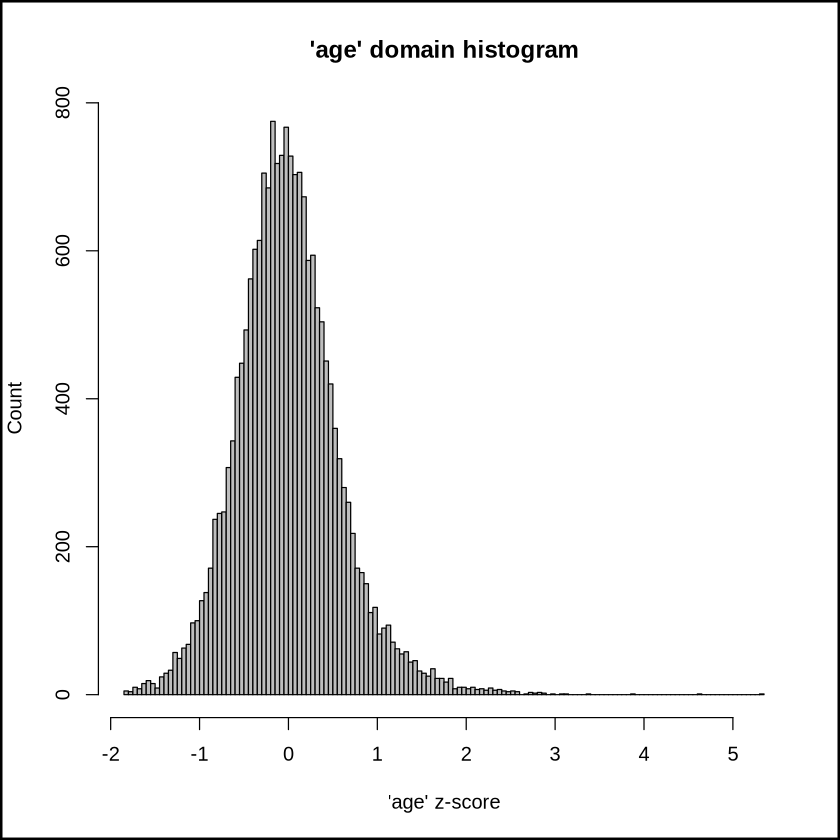

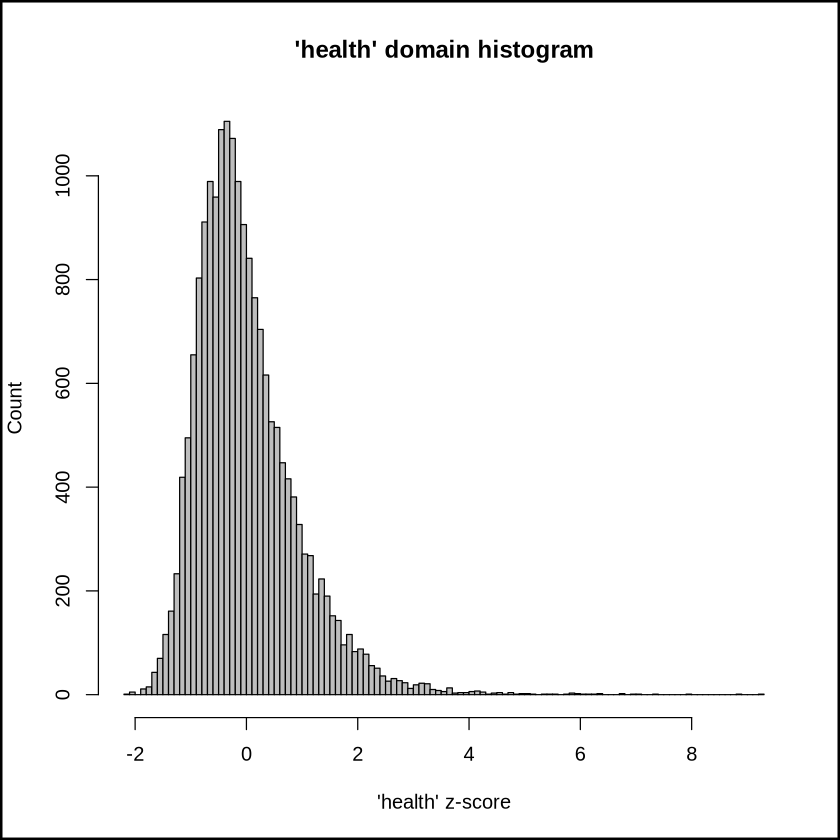

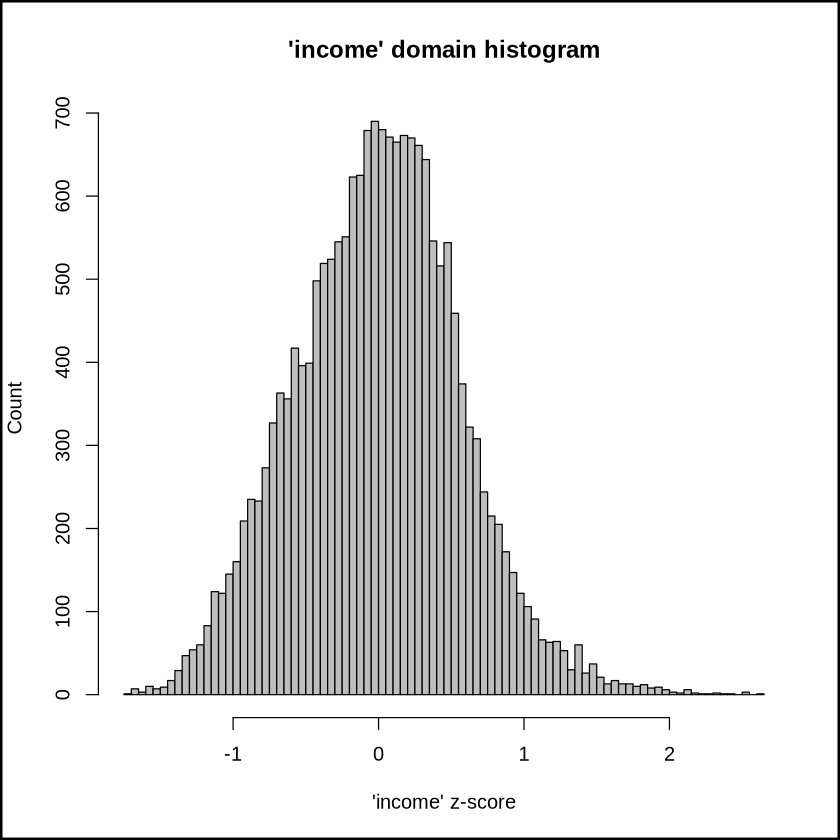

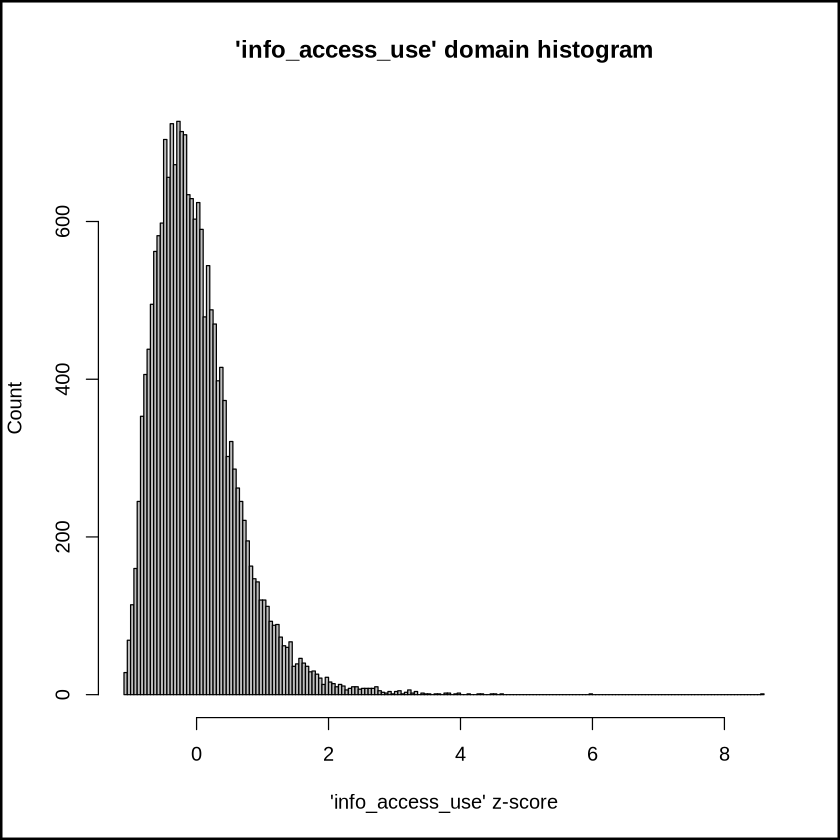

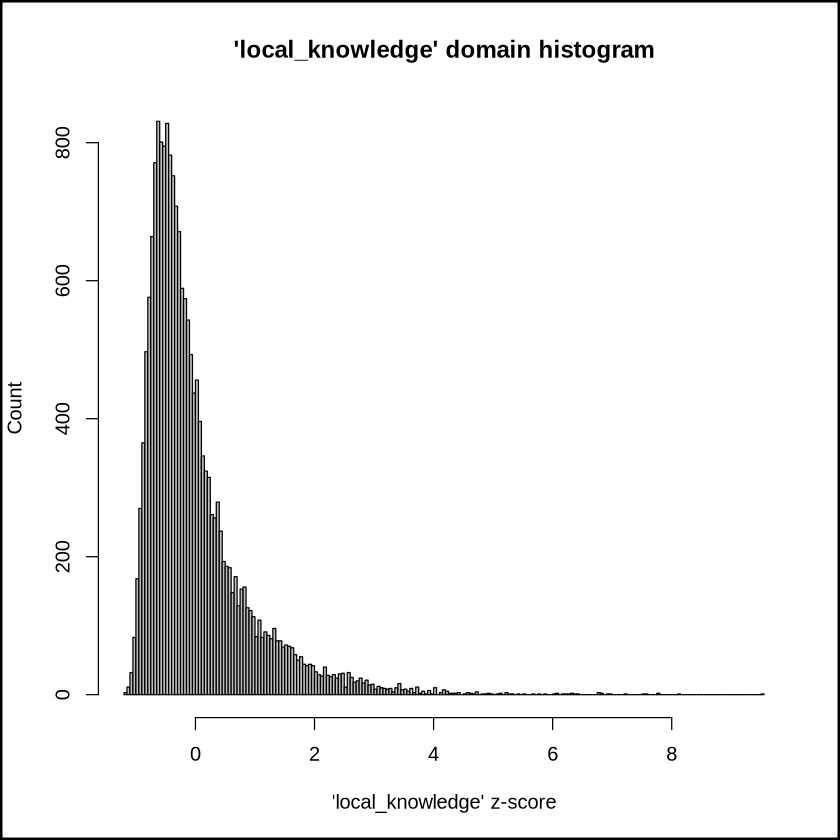

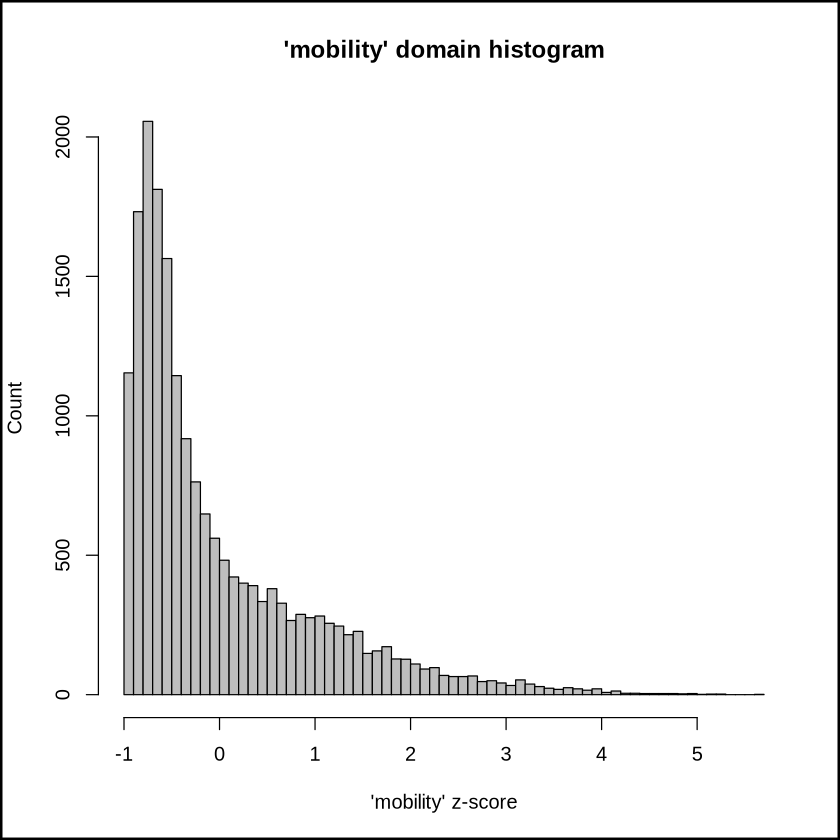

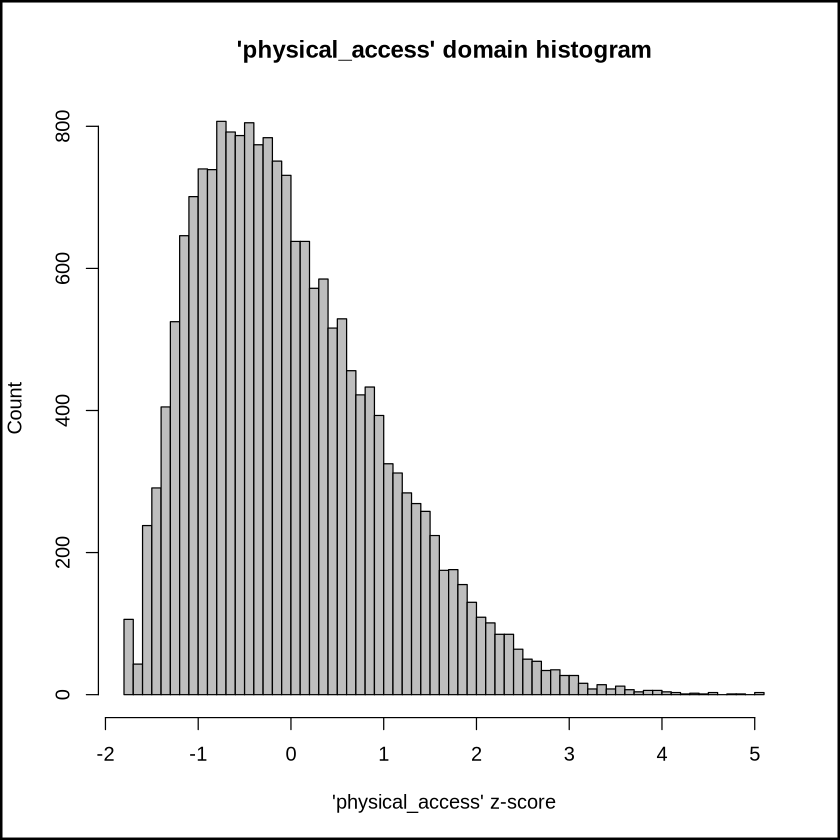

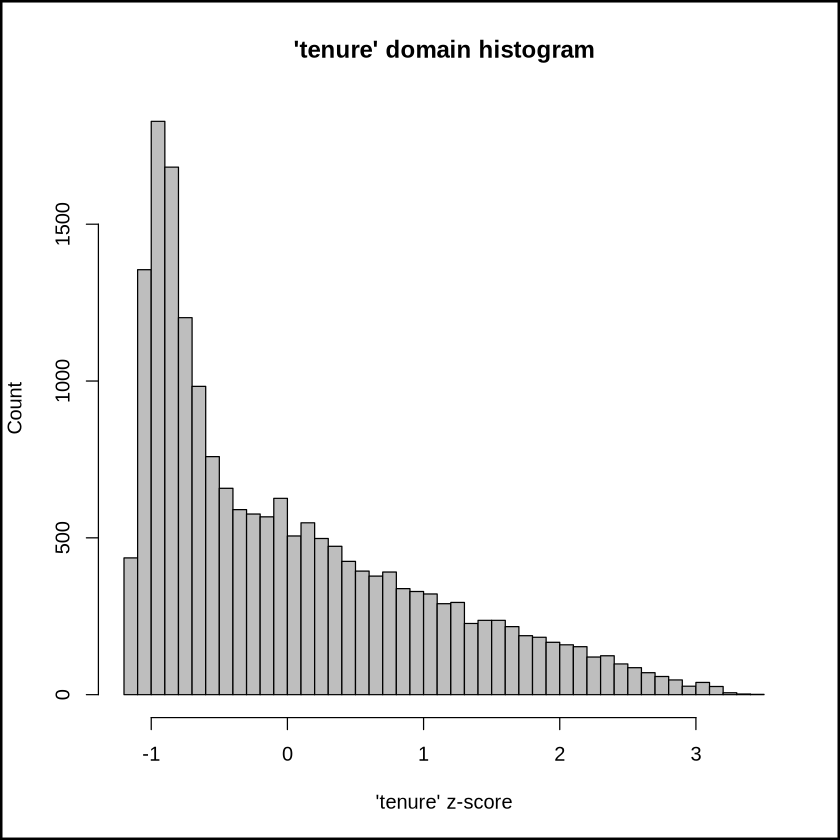

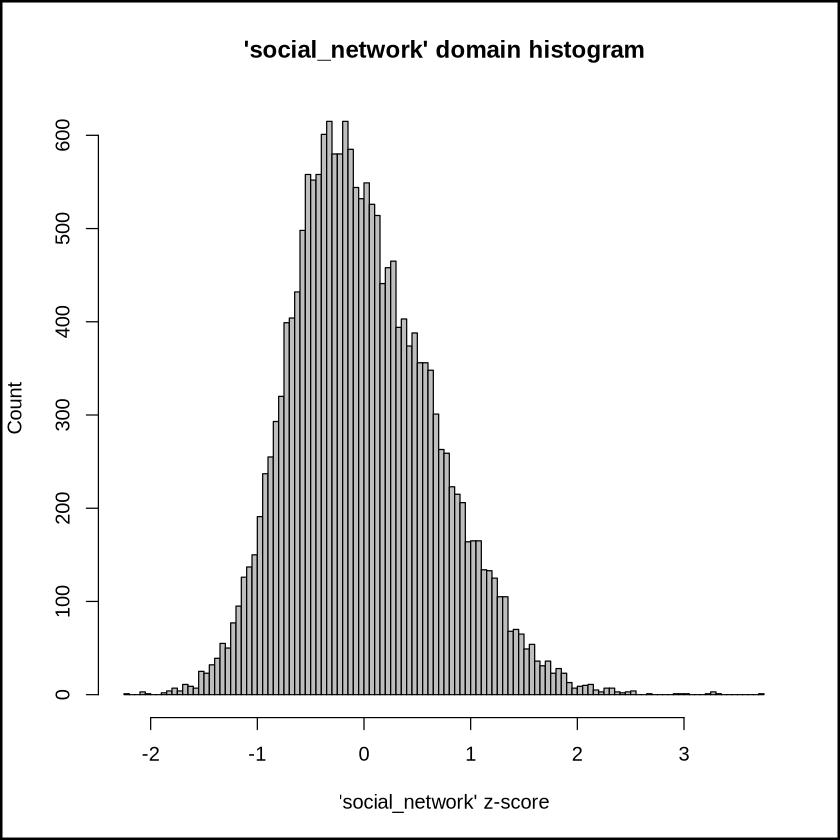

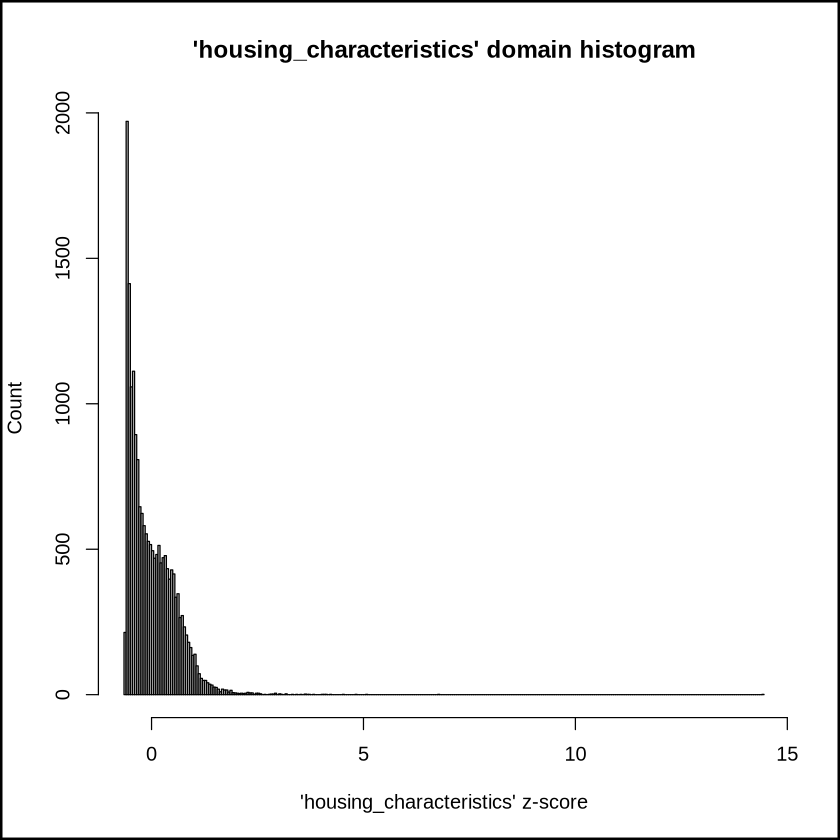

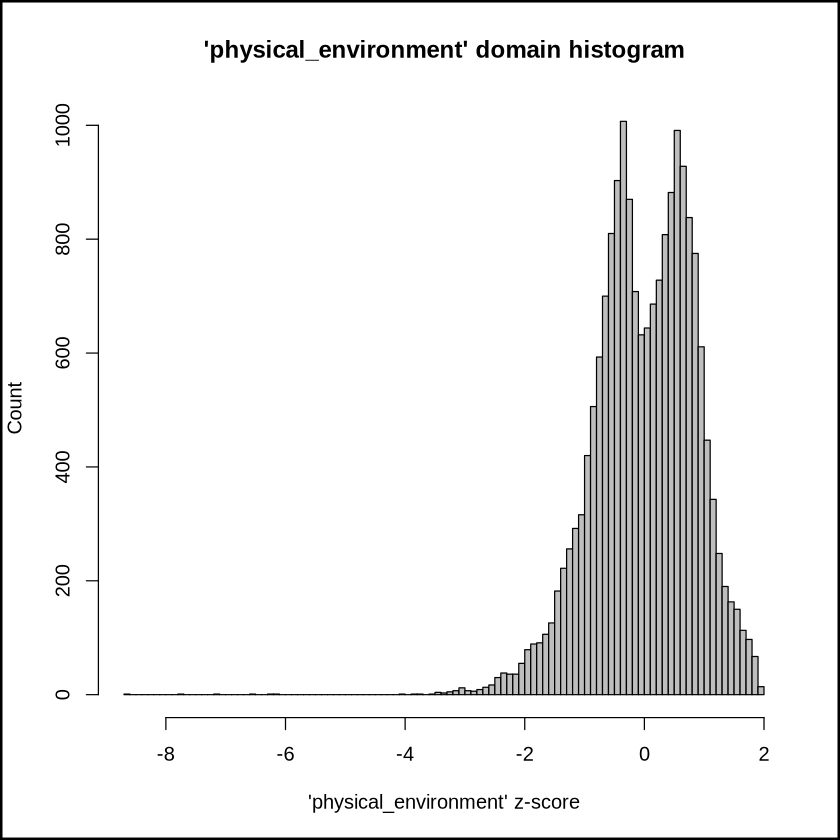

In [9]:
# Histogram visualisation of domain z-scores
for( current_domain in unique_domains ) {
    domain_scores_filtered <- domain_scores[,current_domain] 
    domain_scores_filtered[domain_scores_filtered == "NaN"] <- 0

    title <- paste("'", current_domain, "' domain histogram", sep = "")
    x_label <- paste("'", current_domain, "' z-score", sep = "")
    y_label <- paste("Count", sep = "")
    hist(domain_scores_filtered, breaks="FD", col="grey", labels=FALSE, main=title, xlab=x_label, ylab=y_label)
    box("figure", lwd = 4)
}

### Calculate dimension scores
Need to collate the domains into the dimensions

In [10]:
# Create a vector/array of the dimension names
dimensions <- c('sensitivity', 'prepare', 'respond', 'recover', 'adaptive_capacity', 'enhanced_exposure')

# Get the dimension and their associated indicator ID
dimension_indicators <- indicator_mapping %>% select(c('domain', all_of(dimensions)))
head(dimension_indicators)

# Initialise the dimensions score dataset with the GUID
dimension_scores <- indicator_data_weighted %>% select(all_of(GUID))

# loop through each of the dimensions and:
for (current_dimension in dimensions){
    # Identify which indicators are used within this dimension (current_dimension)
    # Then select the indicators marked with value 1, which means that the indicator is part of the dimension
    current_dimension_info <- dimension_indicators %>% select(c('domain', all_of(current_dimension)))
    current_dimension_info <- current_dimension_info %>% filter(dimension_indicators[, current_dimension] == 1)

    # Get a array/vector of the unique domains in this dimension
    current_dimension_domains <- unique(current_dimension_info$domain)

    # Count the number of domains in this dimension
    dimension_domain_count <- length(current_dimension_domains)

    # Filter the domain scores dataset to only use the domains in the dimension, and add the GUID column name
    current_dimension_data <- domain_scores %>% select(c(all_of(GUID), all_of(current_dimension_domains)))  

    # Sum each data row to get the total score for the dimension
    current_dimension_data[, current_dimension] <- rowSums(current_dimension_data[2:(dimension_domain_count+1)], na.rm = TRUE)

    # Add the current dimension score to the overall results
    dimension_indicator_score <- current_dimension_data %>% select(all_of(GUID), all_of(current_dimension))
    dimension_scores <- merge(dimension_scores, dimension_indicator_score, by=GUID)  
}

# generate z-scores with the scale function in order to standardise the dimension data
dimension_scores <- dimension_scores %>% mutate_if(is.numeric, scale)

# Print the first part of the dimension scores, which are now collated into one table
head(dimension_scores)

,domain,sensitivity,prepare,respond,recover,adaptive_capacity,enhanced_exposure
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
1,age,1,0,0,0,0,0
2,age,1,0,0,0,0,0
3,health,1,0,0,0,0,0
4,health,1,0,0,0,0,0
5,income,0,1,1,1,1,0
6,income,0,1,1,1,1,0


,SA_GUID__1,sensitivity,prepare,respond,recover,adaptive_capacity,enhanced_exposure
,<chr>,"<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>"
1,000581a3-4ebd-4a74-b5f8-0bd78cd7ede5,0.38290372,-0.4856123,-0.3377139,-1.3729086,-0.61316276,-0.3497016
2,00275248-3d78-4fdb-8e5c-8ff1f76aebea,-0.20594059,-1.0185818,-0.9052009,-0.5397312,-1.02866162,-0.2313086
3,002b83e4-5cce-414a-8570-871a50ae0964,-0.09575557,1.3659655,1.7874752,-0.1097374,1.32022239,-0.1301417
4,005eec3f-d746-480f-ae2c-bc6f1151548d,0.46969785,1.3940082,0.8307672,-0.3008060,0.88678611,0.3410119
5,00b00ae4-229d-455d-84f1-d6face4876b1,0.06504954,1.1356657,-0.5626938,-0.3603958,0.06607222,-0.1208251
6,00df2b78-66c8-4009-89e0-0e14e15e4208,-0.61841747,-0.5434782,0.5417954,-1.2756320,0.04443066,-0.3770668


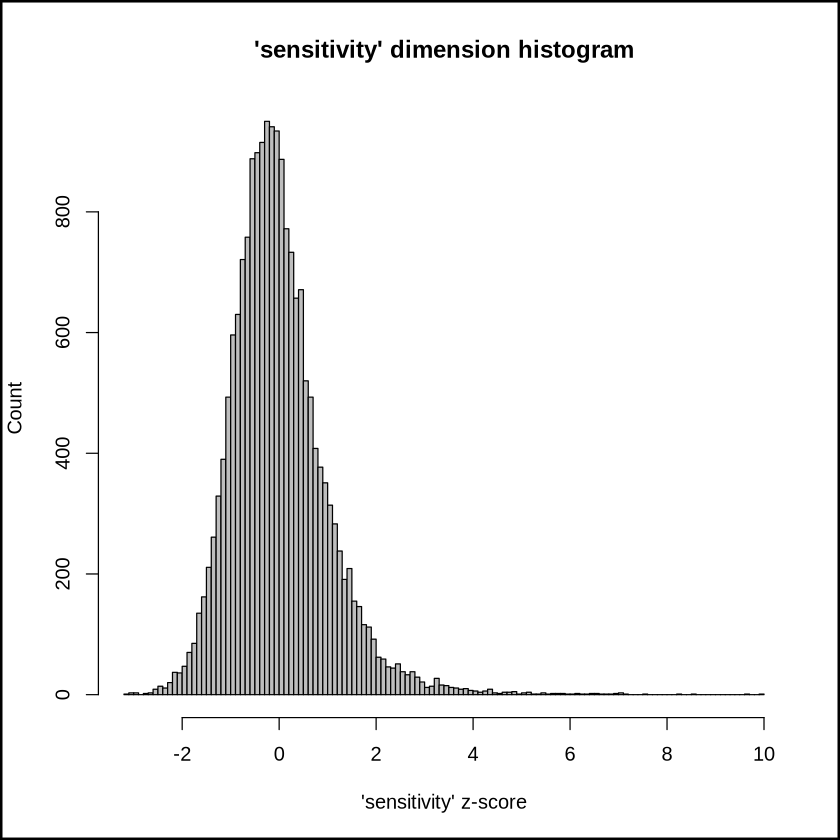

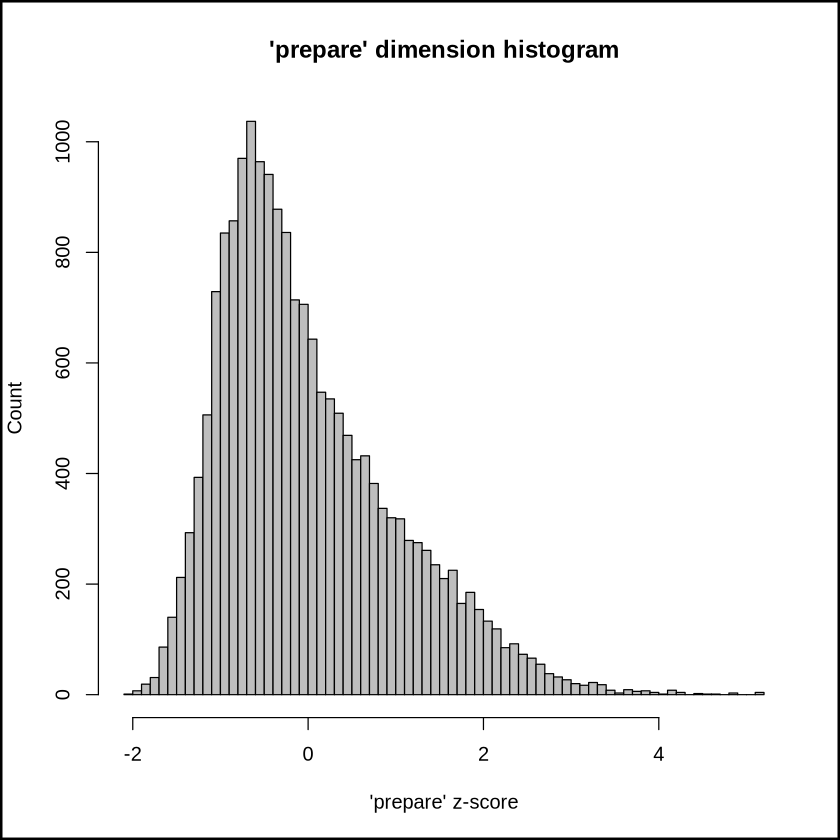

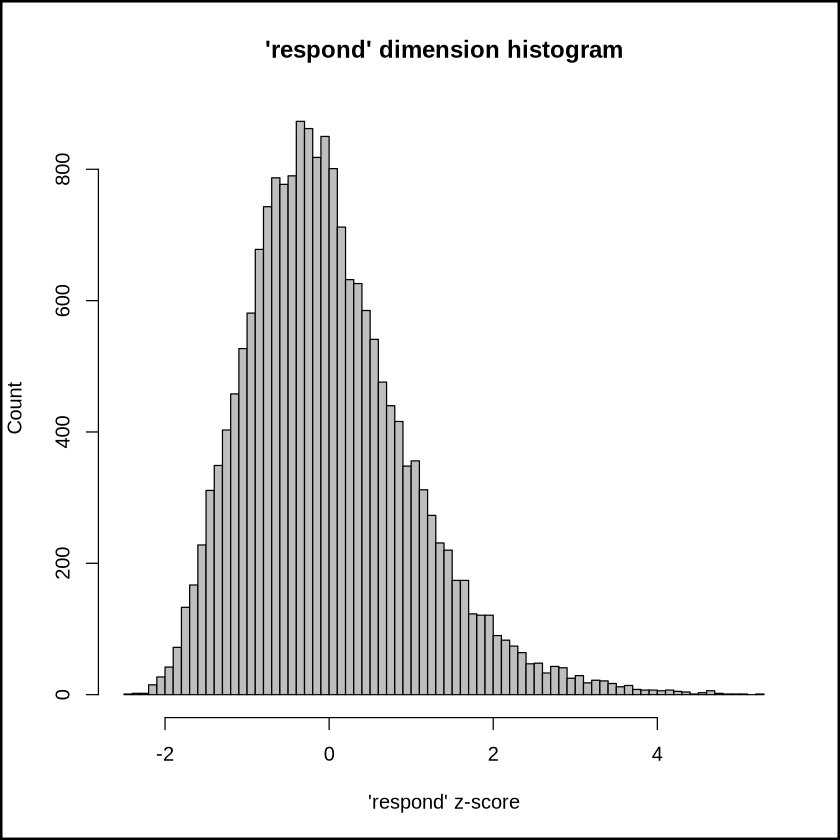

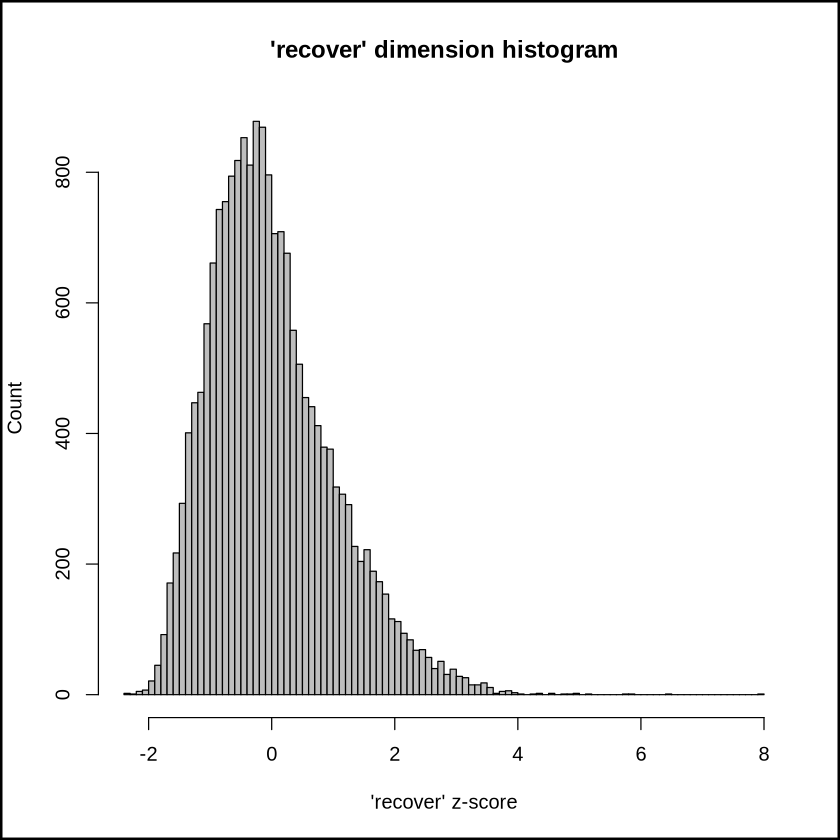

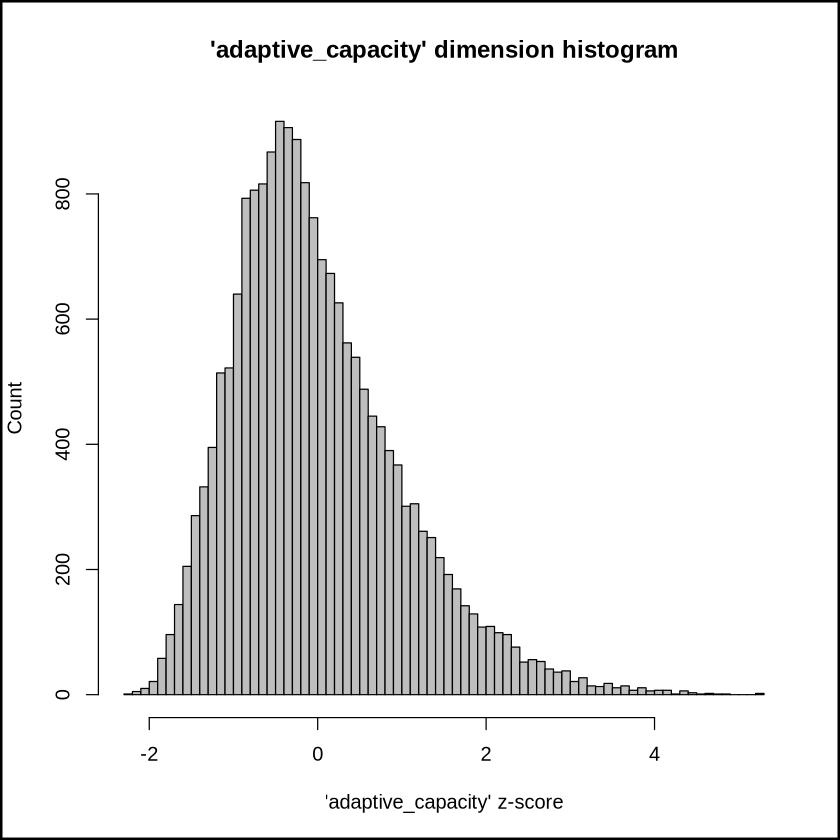

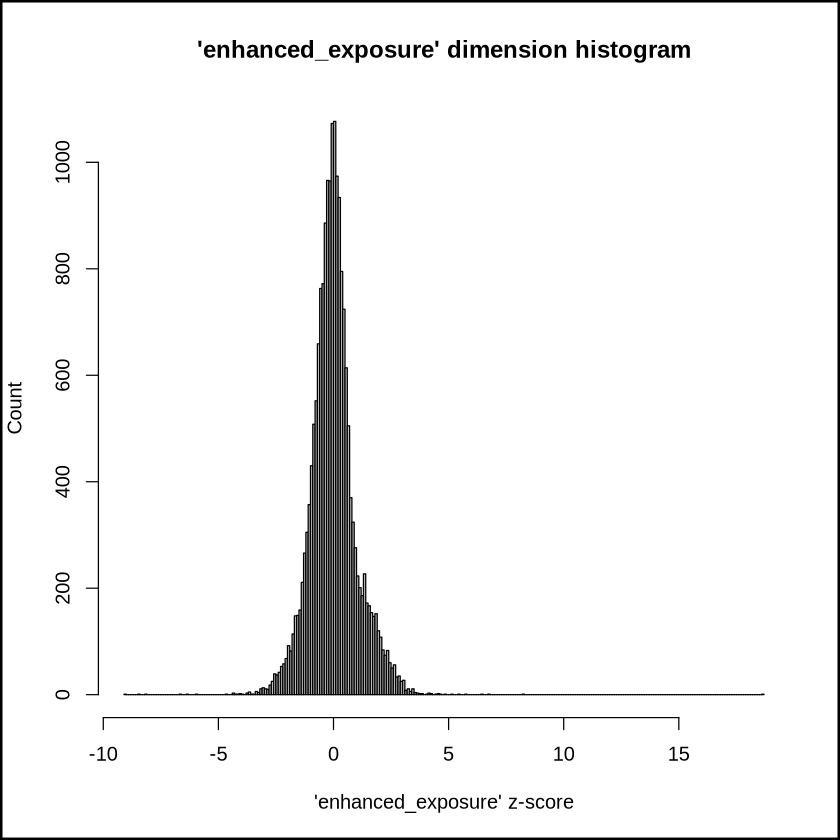

In [11]:
# Histogram visualisation of dimension z-scores
for( current_dimension in dimensions ){
    dimension_scores_filtered <- dimension_scores[,current_dimension] 
    dimension_scores_filtered[dimension_scores_filtered == "NaN"] <- 0
   
    title <- paste("'", current_dimension, "' dimension histogram", sep = "")
    x_label <- paste("'", current_dimension, "' z-score", sep = "")
    y_label <- paste("Count", sep = "")
    hist(dimension_scores_filtered, breaks="FD", col="grey", labels=FALSE, main=title, xlab=x_label, ylab=y_label)
    box("figure", lwd = 4)
}

## Calculate vulnerability score

In [12]:
# Initialise the vulnerability score dataset with the GUID
vulnerability_scores <- domain_scores %>% select(all_of(GUID))

#sum the domains to create a total overall score of vulnerability
vulnerability_scores$social_vulnerability <- rowSums(domain_scores[2:(ncol(domain_scores))], na.rm = TRUE)

# generate z-scores with the scale function in order to standardise the vulnerability data
vulnerability_scores <- vulnerability_scores %>% mutate_if(is.numeric, scale)

# Print the first part of the vulnerability scores, which are now collated into one table
head(vulnerability_scores)

,SA_GUID__1,social_vulnerability
,<chr>,"<dbl[,1]>"
1,000581a3-4ebd-4a74-b5f8-0bd78cd7ede5,-0.33398100
2,00275248-3d78-4fdb-8e5c-8ff1f76aebea,-0.93275401
3,002b83e4-5cce-414a-8570-871a50ae0964,1.13569837
4,005eec3f-d746-480f-ae2c-bc6f1151548d,1.02930797
5,00b00ae4-229d-455d-84f1-d6face4876b1,0.19607516
6,00df2b78-66c8-4009-89e0-0e14e15e4208,-0.09735021


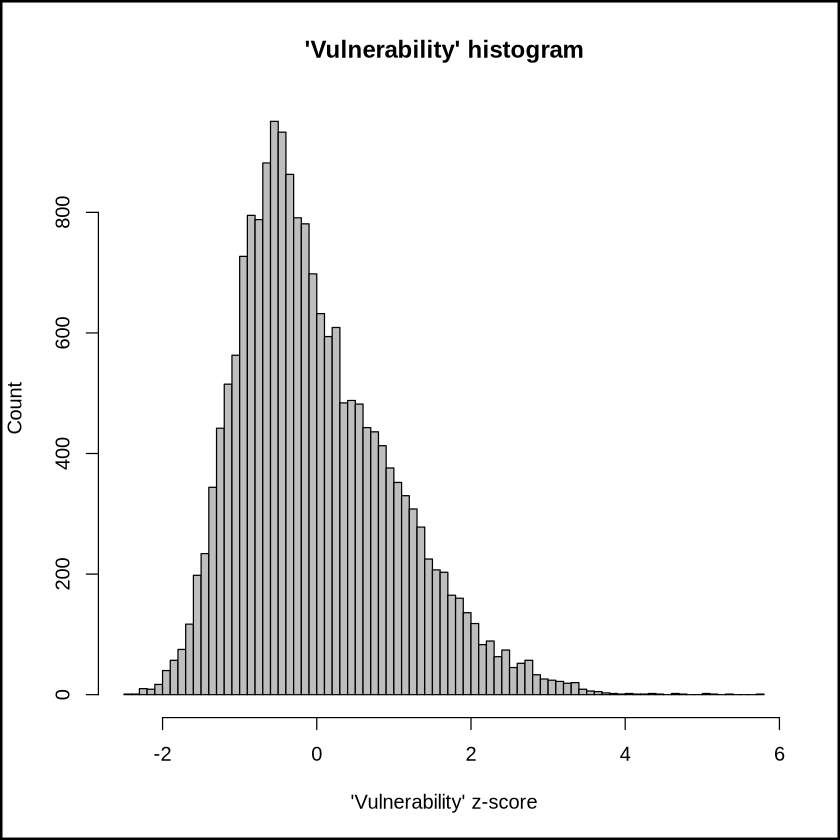

In [13]:
# Histogram visualisation of Vulnerability z-scores
title <- paste("'Vulnerability' histogram", sep = "")
x_label <- paste("'Vulnerability' z-score", sep = "")
y_label <- paste("Count", sep = "")
hist(vulnerability_scores$social_vulnerability, breaks="FD", col="grey", labels=FALSE, main=title, xlab=x_label, ylab=y_label)
box("figure", lwd = 4)

In [14]:
# Merge all the indicators, domains, dimensions, and total vulnerability into one dataset
output_dataset <- merge(indicator_data_weighted, domain_scores, by=GUID)
output_dataset <- merge(output_dataset, dimension_scores, by=GUID)
output_dataset <- merge(output_dataset, vulnerability_scores, by=GUID)

head(output_dataset)

,SA_GUID__1,early_childhood,age_middle_to_oldest_old,poor_health,disability,one_parent_households,three_or_more_children_households,low_skilled_employment,farmers,unemployment,⋯,social_network,housing_characteristics,physical_environment,sensitivity,prepare,respond,recover,adaptive_capacity,enhanced_exposure,social_vulnerability
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,"<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>"
1,000581a3-4ebd-4a74-b5f8-0bd78cd7ede5,3.3880435,-0.8683184,-0.72494112,-0.92235833,-0.9537932,-0.28864382,-0.3191812,-0.5775435,-0.61650259,⋯,-0.76239614,-0.51537733,0.2163239,0.38290372,-0.4856123,-0.3377139,-1.3729086,-0.61316276,-0.3497016,-0.33398100
2,00275248-3d78-4fdb-8e5c-8ff1f76aebea,-1.2041476,1.0830212,0.27801178,-0.62611003,-0.5813707,0.24855343,-0.7175350,0.2814244,-0.23523246,⋯,-0.08583099,-0.08272206,-0.1150856,-0.20594059,-1.0185818,-0.9052009,-0.5397312,-1.02866162,-0.2313086,-0.93275401
3,002b83e4-5cce-414a-8570-871a50ae0964,0.2940109,-0.6563918,0.07647292,0.06773408,0.3083236,-0.06192013,-0.7370951,-0.1126775,0.22240140,⋯,-0.01340725,-0.43095487,0.3196619,-0.09575557,1.3659655,1.7874752,-0.1097374,1.32022239,-0.1301417,1.13569837
4,005eec3f-d746-480f-ae2c-bc6f1151548d,-1.3337162,1.4547264,0.49313225,0.45603900,-1.0918818,-1.18351563,-1.9157382,-0.5775435,-0.07660151,⋯,0.14327742,-0.34810226,0.6397246,0.46969785,1.3940082,0.8307672,-0.3008060,0.88678611,0.3410119,1.02930797
5,00b00ae4-229d-455d-84f1-d6face4876b1,1.7131001,-1.2060316,-0.32805634,-0.03080027,3.2416831,1.26642096,1.5271694,-0.5775435,0.75768133,⋯,-0.81129050,-0.57973227,0.4764065,0.06504954,1.1356657,-0.5626938,-0.3603958,0.06607222,-0.1208251,0.19607516
6,00df2b78-66c8-4009-89e0-0e14e15e4208,1.5084163,-0.8589597,-1.03118100,-1.02730679,-0.4959203,-0.57201990,0.4816479,-0.4599295,-0.97841257,⋯,-0.53257202,-0.50830359,0.1858483,-0.61841747,-0.5434782,0.5417954,-1.2756320,0.04443066,-0.3770668,-0.09735021


## Correlations

In [15]:
# check the correlations
correlation <- cor(output_dataset %>% select(-c(all_of(GUID))), use="pairwise.complete.obs")
correlation

,early_childhood,age_middle_to_oldest_old,poor_health,disability,one_parent_households,three_or_more_children_households,low_skilled_employment,farmers,unemployment,no_higher_education,⋯,social_network,housing_characteristics,physical_environment,sensitivity,prepare,respond,recover,adaptive_capacity,enhanced_exposure,social_vulnerability
early_childhood,1.000000000,-0.32493451,-0.19669611,-0.348783559,0.09850766,0.25303355,0.013435867,-0.01978601,-0.13004664,-0.137898158,⋯,-0.38366160,-0.160256869,-0.03372868,0.056874631,0.00745299,-0.13050168,-0.26465066,-0.12476835,-0.13656575,-0.092781282
age_middle_to_oldest_old,-0.324934515,1.00000000,0.30653419,0.524380117,-0.17156982,-0.21339372,-0.018174118,0.11130965,0.07775926,0.196145051,⋯,0.26164119,0.169576750,-0.13170866,0.660967764,-0.26899725,-0.10851529,0.13857486,-0.15313015,-0.01957992,0.040267361
poor_health,-0.196696114,0.30653419,1.00000000,0.635159460,0.30466708,-0.20580461,0.291697215,-0.13013724,0.57211583,0.424979686,⋯,0.42639629,0.022511126,0.15267300,0.765871577,0.29258876,0.35238297,0.51649964,0.33806981,0.16419232,0.534897413
disability,-0.348783559,0.52438012,0.63515946,1.000000000,0.26578634,-0.26676366,0.279103306,-0.12151826,0.55274473,0.435642179,⋯,0.47151022,0.042917765,0.10336068,0.794732682,0.17260065,0.27259948,0.49373907,0.25145006,0.12903530,0.461766118
one_parent_households,0.098507657,-0.17156982,0.30466708,0.265786342,1.00000000,0.13073343,0.399706920,-0.22809509,0.52557353,0.268872631,⋯,0.03932941,-0.253554724,0.20588712,0.218302790,0.40820193,0.24661411,0.28460567,0.27320175,0.03805277,0.332412186
three_or_more_children_households,0.253033549,-0.21339372,-0.20580461,-0.266763657,0.13073343,1.00000000,0.120114454,0.27576238,-0.12234336,-0.066259317,⋯,-0.68726343,-0.075504006,-0.31261976,-0.190010345,-0.27880835,-0.39096576,-0.39137609,-0.41701881,-0.35520161,-0.464972587
low_skilled_employment,0.013435867,-0.01817412,0.29169722,0.279103306,0.39970692,0.12011445,1.000000000,0.06854214,0.44466332,0.385397713,⋯,0.07614730,-0.027756007,-0.04957132,0.248442188,0.25359005,0.23286477,0.35800972,0.18890973,-0.06651743,0.217004201
farmers,-0.019786008,0.11130965,-0.13013724,-0.121518259,-0.22809509,0.27576238,0.068542137,1.00000000,-0.09975730,0.097044899,⋯,-0.24591427,0.504804657,-0.53228034,-0.070281154,-0.23117977,-0.16727776,0.01664975,-0.17952180,-0.19571665,-0.282746200
unemployment,-0.130046641,0.07775926,0.57211583,0.552744730,0.52557353,-0.12234336,0.444663319,-0.09975730,1.00000000,0.560757353,⋯,0.42159647,0.043276112,0.14323937,0.470747553,0.52914364,0.49626060,0.67751217,0.50210064,0.16835665,0.580520974
no_higher_education,-0.137898158,0.19614505,0.42497969,0.435642179,0.26887263,-0.06625932,0.385397713,0.09704490,0.56075735,1.000000000,⋯,0.29491114,0.151364799,-0.03472561,0.403287370,0.32913634,0.37864876,0.57496105,0.33645163,0.06372239,0.386552633


## Add geometry

In [16]:
# add st_drop_geometry
output_dataset_geom <- merge(output_dataset, oa, by.x=GUID, by.y=GUID, all.x = TRUE)
head(output_dataset_geom)

,SA_GUID__1,early_childhood,age_middle_to_oldest_old,poor_health,disability,one_parent_households,three_or_more_children_households,low_skilled_employment,farmers,unemployment,⋯,housing_characteristics,physical_environment,sensitivity,prepare,respond,recover,adaptive_capacity,enhanced_exposure,social_vulnerability,geometry
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,"<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>","<dbl[,1]>",<MULTIPOLYGON [m]>
1,000581a3-4ebd-4a74-b5f8-0bd78cd7ede5,3.3880435,-0.8683184,-0.72494112,-0.92235833,-0.9537932,-0.28864382,-0.3191812,-0.5775435,-0.61650259,⋯,-0.51537733,0.2163239,0.38290372,-0.4856123,-0.3377139,-1.3729086,-0.61316276,-0.3497016,-0.33398100,MULTIPOLYGON (((676048.9 72...
2,00275248-3d78-4fdb-8e5c-8ff1f76aebea,-1.2041476,1.0830212,0.27801178,-0.62611003,-0.5813707,0.24855343,-0.7175350,0.2814244,-0.23523246,⋯,-0.08272206,-0.1150856,-0.20594059,-1.0185818,-0.9052009,-0.5397312,-1.02866162,-0.2313086,-0.93275401,MULTIPOLYGON (((637187.3 72...
3,002b83e4-5cce-414a-8570-871a50ae0964,0.2940109,-0.6563918,0.07647292,0.06773408,0.3083236,-0.06192013,-0.7370951,-0.1126775,0.22240140,⋯,-0.43095487,0.3196619,-0.09575557,1.3659655,1.7874752,-0.1097374,1.32022239,-0.1301417,1.13569837,MULTIPOLYGON (((645674.5 69...
4,005eec3f-d746-480f-ae2c-bc6f1151548d,-1.3337162,1.4547264,0.49313225,0.45603900,-1.0918818,-1.18351563,-1.9157382,-0.5775435,-0.07660151,⋯,-0.34810226,0.6397246,0.46969785,1.3940082,0.8307672,-0.3008060,0.88678611,0.3410119,1.02930797,MULTIPOLYGON (((716705.1 72...
5,00b00ae4-229d-455d-84f1-d6face4876b1,1.7131001,-1.2060316,-0.32805634,-0.03080027,3.2416831,1.26642096,1.5271694,-0.5775435,0.75768133,⋯,-0.57973227,0.4764065,0.06504954,1.1356657,-0.5626938,-0.3603958,0.06607222,-0.1208251,0.19607516,MULTIPOLYGON (((697195.3 79...
6,00df2b78-66c8-4009-89e0-0e14e15e4208,1.5084163,-0.8589597,-1.03118100,-1.02730679,-0.4959203,-0.57201990,0.4816479,-0.4599295,-0.97841257,⋯,-0.50830359,0.1858483,-0.61841747,-0.5434782,0.5417954,-1.2756320,0.04443066,-0.3770668,-0.09735021,MULTIPOLYGON (((662960.4 71...


# Export

In [17]:
# CSV
write.csv(output_dataset, file.path(output_dir, "social_vulnerability_index_ireland_2022.csv"), row.names = FALSE)

# GeoJSON
st_write(output_dataset_geom, file.path(output_dir, "social_vulnerability_index_ireland_2022.geojson"), delete_dsn=TRUE)

# Shapefile
st_write(output_dataset_geom, file.path(output_dir, "social_vulnerability_index_ireland_2022.shp"), append = FALSE)

Deleting source `../../3_outputs/Ireland/2022/social_vulnerability_index_ireland_2022.geojson' using driver `GeoJSON'
Writing layer `social_vulnerability_index_ireland_2022' to data source 
  `../../3_outputs/Ireland/2022/social_vulnerability_index_ireland_2022.geojson' using driver `GeoJSON'
Writing 18919 features with 46 fields and geometry type Multi Polygon.


Warning message in abbreviate_shapefile_names(obj):
“Field names abbreviated for ESRI Shapefile driver”


Deleting layer `social_vulnerability_index_ireland_2022' using driver `ESRI Shapefile'
Writing layer `social_vulnerability_index_ireland_2022' to data source 
  `../../3_outputs/Ireland/2022/social_vulnerability_index_ireland_2022.shp' using driver `ESRI Shapefile'
Writing 18919 features with 46 fields and geometry type Multi Polygon.


**END**